## Introduction

### Contexte

L'agence Santé publique France souhaite améliorer sa base de données Open Food Facts et fait appel aux services de votre entreprise. Cette base de données open source est mise à la disposition de particuliers et d’organisations afin de leur permettre de connaître la qualité nutritionnelle de produits. 
 
Aujourd’hui, pour ajouter un produit à la base de données d'Open Food Facts, il est nécessaire de remplir de nombreux champs textuels et numériques, ce qui peut conduire à des erreurs de saisie et à des valeurs manquantes dans la base. 

L’agence Santé publique France confie à votre entreprise la création d’un système de suggestion ou d’auto-complétion pour aider les usagers à remplir plus efficacement la base de données. Dans un premier temps, vous devez vous concentrer sur la prise en main des données, et d’abord les nettoyer et les explorer. 

### Problématique

__Est-il possible de suggérer des valeurs pour certains champs lors de l'ajout d'un nouveau produit afin de réduire les erreurs de saisie et les valeurs manquantes dans la base de données Open Food Facts ?__

### Objectifs

- Identifier les variables cibles pour lesquelles il serait pertinent de suggérer des valeurs (plus de 50% de valeurs manquantes).
- Identifier les variables nécessaires pour lesquelles il est important d'avoir des données.
- Filtrer 
- Mettre en évidence les valeurs manquantes
- Identifier 3 méthodes adaptées (métiers) pour traiter ces valeurs manquantes.
- Automatiser les traitements pour éviter de répéter les opérations.


- Se servir de ces variables nécessaires pour tenter de faire des suggestions sur les variables avec des valeurs manquantes.

- Etablir la faisabilité de suggérer les valeurs manquantes pour une variable dont plus de 50% des valeurs sont manquantes.

### About RGPD

- Expliquer que la RGPD ne s'applique que dans le cadre de la manipulation de données personnelles.
- Détailler les grands principes des RGPD et en quoi ce projet reste tout de même cohérent avec ces principes.
- Expliquer ce qu'et une donnée personnelle et conclure que dans ce projet n'a pas de lien avec les RGPD.

## Imports and setup

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install missingno
%pip install googletrans==4.0.0-rc1
%pip install geopy
%pip install tqdm
%pip install -U scikit-learn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
from typing import Optional, Callable
import missingno as msno
import re
import math
from googletrans import Translator
from tqdm import tqdm
from functools import partial
from geopy.geocoders import Nominatim
from httpx import Timeout
from tqdm import tqdm
# from sklearn.feature_selection import f_classif
import cProfile
tqdm.pandas()

In [2]:
timeout=Timeout(10.0)
translator = Translator(user_agent="DS-3", timeout=timeout)

In [3]:
# Data collection

# Using low_memory = False to remove the DTypeWarning resulted in "code" column being modified.
# For example :
# low_memory = True : 11778, 11778
# low_memory = False : 0011778, 00011778
# All duplicates seem to be removed like this with low_memory = False

# Collect data and store it in a DataFrame
products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)

C:\Users\HCYF5290\AppData\Local\Temp\1\ipykernel_25232\3640485078.py:10: DtypeWarning: Columns (0,3,5,19,20,24,25,26,27,28,35,36,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)


In [4]:
def check_for_mixed_types(df:pd.DataFrame) -> list:
    '''
    Checks a DataFrame for columns with inconsistent types.

    Parameters:
    df (pd.Dataframe): DataFrame to check

    Returns:
    List of column with inconsistent types.
    '''
    cols_mixed_types = []
    for col in df.columns:
        weird = (df[[col]].map(type) != df[[col]].iloc[0].apply(type)).any(axis=1)
        if len(df[weird]) > 0:
            cols_mixed_types.append(col)
    
    print(f"{len(cols_mixed_types)} column(s) have inconsistent types.")
    
    return cols_mixed_types

In [38]:
check_for_mixed_types(products)

55 column(s) have inconsistent types.


['code',
 'url',
 'creator',
 'created_t',
 'created_datetime',
 'last_modified_t',
 'product_name',
 'generic_name',
 'quantity',
 'packaging',
 'packaging_tags',
 'brands',
 'brands_tags',
 'categories',
 'categories_tags',
 'categories_fr',
 'origins',
 'origins_tags',
 'manufacturing_places',
 'manufacturing_places_tags',
 'labels',
 'labels_tags',
 'labels_fr',
 'emb_codes',
 'emb_codes_tags',
 'first_packaging_code_geo',
 'cities',
 'cities_tags',
 'purchase_places',
 'stores',
 'countries',
 'countries_tags',
 'countries_fr',
 'ingredients_text',
 'allergens',
 'allergens_fr',
 'traces',
 'traces_tags',
 'traces_fr',
 'serving_size',
 'additives',
 'additives_tags',
 'additives_fr',
 'ingredients_from_palm_oil_tags',
 'ingredients_that_may_be_from_palm_oil_tags',
 'nutrition_grade_fr',
 'pnns_groups_1',
 'pnns_groups_2',
 'states',
 'states_tags',
 'states_fr',
 'main_category',
 'main_category_fr',
 'image_url',
 'image_small_url']

Mixed types are due to the fact that "read_csv" method is reading the csv by chunks when "low_memory" parameter is set to True.
If there are a lot of missing values, some chunks might only contain NaN values and therefore be considered as "float".

In [4]:
# Set the seaborn theme for plots
sns.set_theme(palette="dark")

## General and basic data exploration

In [8]:
products.dtypes.head(60)

code                                           object
url                                            object
creator                                        object
created_t                                      object
created_datetime                               object
last_modified_t                                object
last_modified_datetime                         object
product_name                                   object
generic_name                                   object
quantity                                       object
packaging                                      object
packaging_tags                                 object
brands                                         object
brands_tags                                    object
categories                                     object
categories_tags                                object
categories_fr                                  object
origins                                        object
origins_tags                

<Axes: >

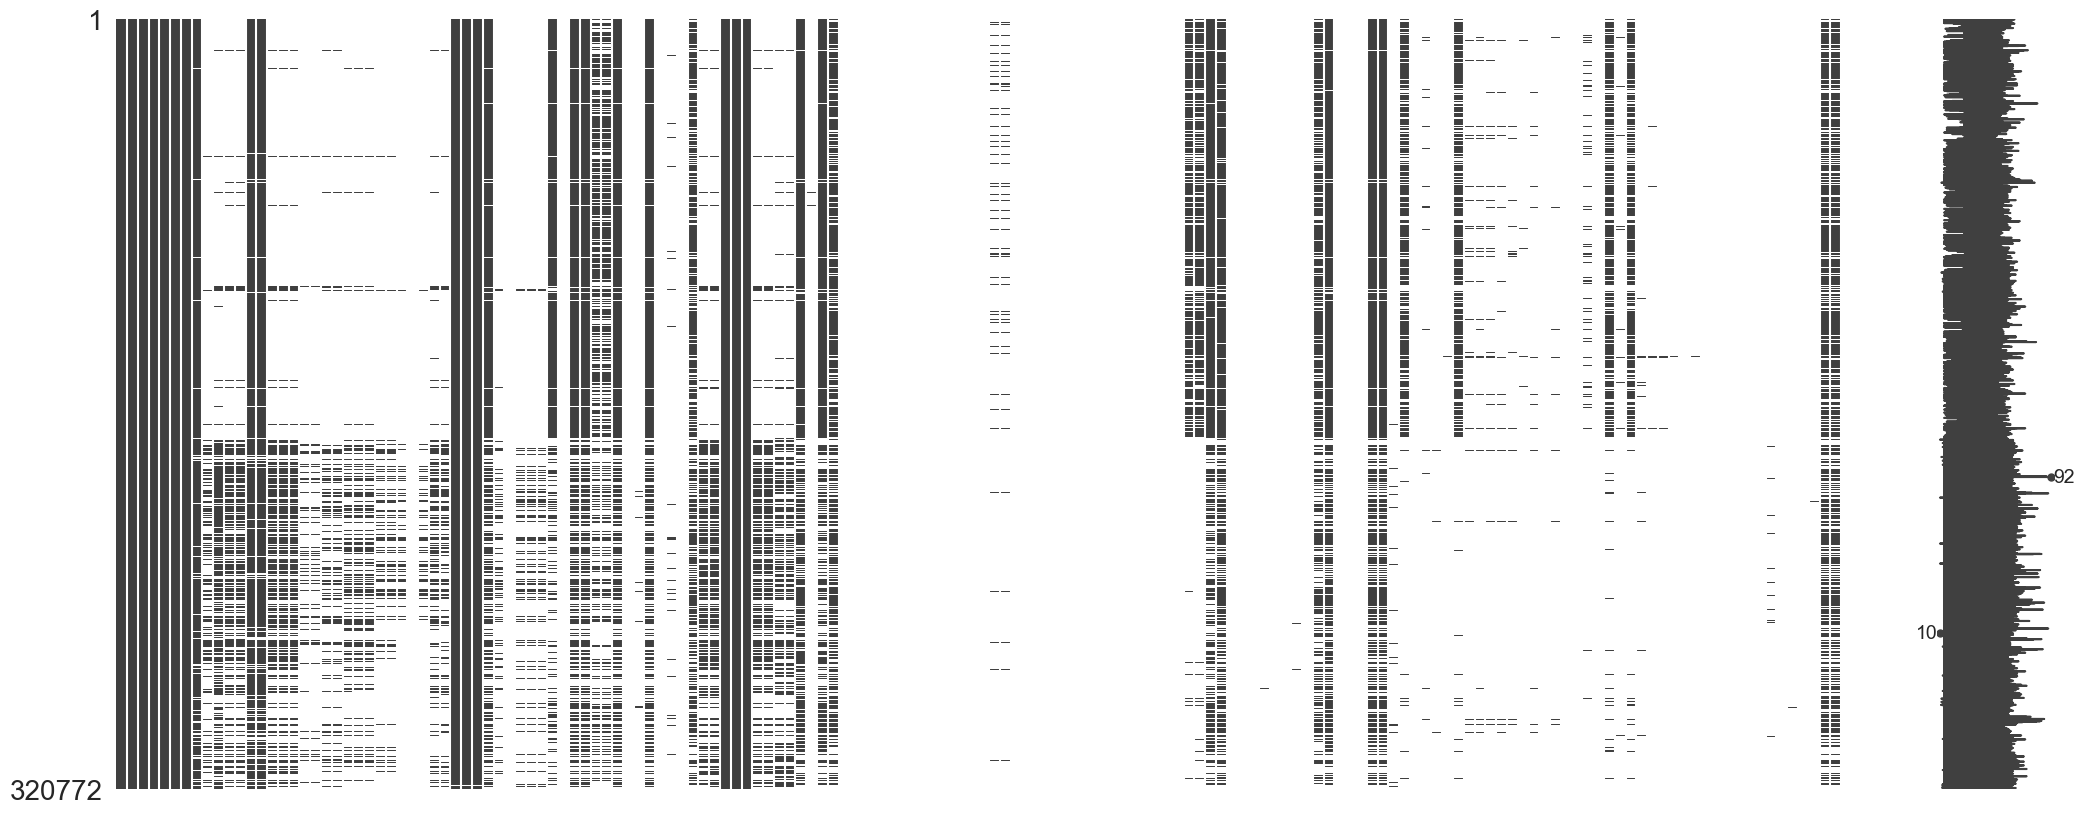

In [7]:
# Visualize missing values
msno.matrix(products)

In [5]:
def display_unique_values(s:pd.Series, df:pd.DataFrame):
    n_unique_values = df.loc[s.name, "nbr_unique_values"]
    if n_unique_values == 0:
        return "no value"
    if n_unique_values < 6:
        return ", ".join(f"{s.value_counts().index[i]} ({v} occurrences)" for i, v in enumerate(s.value_counts()))
    
    return "too many to display"


def add_additional_comment(s:pd.Series, df:pd.DataFrame, sensitivity:float):   
    value_counts = s.value_counts()

    if len(value_counts) > 0:
        # Calculate top common values based on sensitivity
        n_top_common_values = int(len(value_counts) * sensitivity)
        top_common_values = value_counts.values[:n_top_common_values]
        
        # Check if the top common values represent a significant proportion of the data
        if value_counts.quantile(1 - sensitivity) / value_counts.max() < 0.25 and n_top_common_values <= 10:
            sum_top_common_values = top_common_values.sum()
            top_common_values_prop = round(sum_top_common_values / df.loc[s.name, "nbr_non_null_values"], 2)
            top_common_values_info = [f"{value_counts.index[i]} ({value})" for i, value in enumerate(top_common_values)]
            
            # Print additional comments on common values
            return f"""First {n_top_common_values} unique values represent {top_common_values_prop * 100}% of total values : {', '.join(top_common_values_info)}"""
        
        return
    
    else:
        return "This column only contains null values."


def compute_modes(s:pd.Series):
    value_counts = s.value_counts()
    modes = s.mode()
    n_modes = len(modes)

    if n_modes > 0:
        return ", ".join(str(v) if i < 3 else f"... ({n_modes} elements)" for i, v in enumerate(modes[:min(n_modes, 4)])) + f" ({value_counts.values[0]} occurrence(s))"
    
    return


def get_df_variables_info(df:pd.DataFrame) -> pd.DataFrame:

    (n_rows, n_columns) = df.shape
    print(f"This DataFrame has {n_rows} rows and {n_columns} columns.")
    
    top_common_values_sensitivity = 0.15

    n_unique_values = df.nunique()
    n_values = df.count()

    df_info = pd.DataFrame({
        'column_type':df.dtypes,
        'missing_value_percentage': (df.isnull().mean()*100).round(3),
        'nbr_unique_values': n_unique_values,
        'nbr_null_values': df.isnull().sum(),
        'nbr_non_null_values': n_values,
        'duplicates_percentage':round(100-n_unique_values/(n_values.where(n_values != 0, np.nan))*100, 2),
        'mode': df.apply(compute_modes),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(numeric_only=True)
        })

    df_info["unique_values"] = df.apply(display_unique_values, df=df_info)
    df_info["additional_comment"] = df.apply(add_additional_comment, df=df_info, sensitivity=top_common_values_sensitivity)

    return df_info


In [9]:
products_info = get_df_variables_info(products)

This DataFrame has 320772 rows and 162 columns.


## Dtypes fixes

### Incorrect datetime formats

Columns "last_modified_datetime" and "created_datetime" should be of dtype "datetime64[ns]". Let's try to convert them.

In [10]:
products["last_modified_datetime"] = pd.to_datetime(products["last_modified_datetime"])

ValueError: time data "en:belgium,en:france" doesn't match format "%Y-%m-%dT%H:%M:%S%z", at position 62064. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Some datetime values are not formatted correctly. Let's identify the products that have this issue.

In [6]:
# Create a new column with formatted datetime, and highlight errors with NaT.
products["last_modified_datetime_formatted"] = pd.to_datetime(products["last_modified_datetime"], errors='coerce')
products["created_datetime_formatted"] = pd.to_datetime(products["created_datetime"], errors='coerce')

annoying_products = products.loc[products["last_modified_datetime_formatted"].isna() | products["created_datetime_formatted"].isna()]

print(f"Here are the {len(annoying_products)} products with incorrect datetime format:")
annoying_products[["code", "product_name", "created_datetime", "last_modified_datetime"]]

Here are the 24 products with incorrect datetime format:


,code,product_name,created_datetime,last_modified_datetime
187478,3017760038409,Lulu la barquette (Fraise),NaN,2017-03-08T16:54:15Z
189068,NaN,"Belgique,France",NaN,"en:belgium,en:france"
189103,NaN,France,"Dia,Sogeres",en:france
189109,NaN,"Belgique,France,Suisse",NaN,"en:belgium,en:france,en:switzerland"
189119,NaN,France,SuperU,en:france
189152,NaN,France,Carrefour,en:france
189160,NaN,France,NaN,en:france
189162,NaN,France,Auchan,en:france
189168,NaN,France,NaN,en:france
189242,NaN,France,Carrefour market,en:france


Columns seem to have been mixed for most of those products. Reorganizing values in their correct column is quite difficult since there is no information on the product "code".
Those lines will just be dropped because it doesn't represent much data.  
Only index "187478" will be kept because it is a special case : all columns are correctly assigned, only the created_datetime and created_t are weird.  


In [7]:
# Remove index 187478 from annoying products
annoying_products = annoying_products.drop(index=187478)

# Remove annoying products from products
products = products.drop(index=annoying_products.index).reset_index(drop=True)

# Replace missing created_datetime with corresponding last_modified_datetime
# Ideally, we could impute created_datetime value based on created_t column, but created_t is 0 for index 187478.
products.loc[187478, "created_datetime_formatted"] = products.loc[187478, "last_modified_datetime_formatted"]

# Replace "created_datetime" with custom "created_datetime_formatted" column
products["created_datetime"] = products["created_datetime_formatted"]
# Replace "last_modified_datetime" with custom "last_modified_datetime_formatted" column
products["last_modified_datetime"] = products["last_modified_datetime_formatted"]
# Remove custom columns created previously to identify incorrect date formats
products = products.drop(columns=["created_datetime_formatted", "last_modified_datetime_formatted"])

### Minor notes

Columns "ingredients_from_palm_oil" and "ingredients_that_may_be_from_palm_oil" should be of type "object" instead of "float64", but since there are only null values it doesn't really matter.  
Same thing for column "nutrition_grade_uk".

In [18]:
# Update products_info
products_info = get_df_variables_info(products)

This DataFrame has 320749 rows and 162 columns.


## Data cleaning

### Similar columns

According to description of fields from the provided documentation :  

> "fields that end with _tags are comma separated list of tags (e.g. categories_tags is the set of normalized tags computed from the categories field)"

Therefore, when several columns contain the same data ("countries", "countries_tags" and "countries_fr" for example), the column wth suffix "_tags" will be preferred because it is normalized.

However, some similar columns do not have the same amount of non-null values.

In [8]:
def compare_similar_columns_missing_values(df:pd.DataFrame, base_col_name:str, include_columns:list[str]=["product_name"], exclude_columns:list[str]=[]):
    # Get other simimar columns
    columns = [c for c in products if c.startswith(base_col_name) and c not in exclude_columns]

    # Look for products with at least 1 missing value among the columns AND 1 non missing value among the columns
    n_values = df[columns].count(axis=1) # Count non missing values among the columns
    condition = np.logical_and(1 <= n_values, n_values < len(columns)) # Build the condition

    return df.loc[condition, include_columns + columns] # Return products matching the condition

In [ ]:
compare_similar_columns_missing_values(df=products, base_col_name="brands")

,product_name,brands,brands_tags
181735,Grana padano,?,NaN
184680,Wortel selder salade,/,NaN
186293,Camembert rustique,/,NaN
191650,Le Centurion Emmental En Tranchettes,??,NaN
214423,Lait fermenté,--,NaN
234196,Mami nova gourmand,.,NaN
248209,[n. a!] Nature Addicts Rice Crackers Paprika,NaN,na
248211,My mix Blue Boost,NaN,na
251872,Muffins bio au seigle,?,NaN
264490,Deutsche Markenbutter,-,NaN


It seems some values should actually be considered as missing values.  
Let's identify as many of those hidden missing values as possible in the columns of type "object".

In [9]:
def standardize_str(s:str, escape_chars:list=[]):
    if pd.isnull(s):
        return s
    escape_pattern = ''.join(re.escape(char) for char in escape_chars)
    pattern = r'[^\w' + escape_pattern + r']'
    return re.sub(pattern, '', str(s)).lower()

In [10]:
def find_hidden_missing_values(df:pd.DataFrame, standardize:bool=True, print_result:bool = True, impute_nan:bool=False, additional_hidden_null_values:list[str] = ["unknown", "null", "nan", "na", "0", "inconnu", "unavailable", "not stated"]):   
    df_copy = df.copy()

    for col in df_copy:
        if standardize:
            data = df_copy[col].map(standardize_str)
        else:
            data = df_copy[col]
        contains_alphanumeric = data.str.contains(pat=r'\w', na=True, regex=True)
        hidden_null_values_condition = ~contains_alphanumeric | data.isin(additional_hidden_null_values)
        
        if hidden_null_values_condition.any():
            if print_result:
                hidden_null_values = df_copy.loc[hidden_null_values_condition, col]
                print(f"{col}:\n{hidden_null_values}\n{'*'*30}\n")
            if impute_nan:
                df_copy.loc[hidden_null_values_condition, col] = np.nan
    
    return df_copy

In [11]:
# Identify columns with type "object", which can contain hidden null values.
products_object_columns = products.select_dtypes(include=object)
# Remove columns with only null values
products_object_columns = products_object_columns.dropna(axis='columns', how='all')

In [23]:
find_hidden_missing_values(df=products_object_columns, standardize=True, print_result=True, impute_nan=False)

KeyboardInterrupt: 

In [12]:
# Fix some product names after checking their page using the provided url
products.loc[268391, "product_name"] = "5 stars"
products.loc[268392, "product_name"] = "3 stars"
products.loc[315650, "product_name"] = "Dors Tequila"

In [13]:
# Update products_objects_columns to take last changes into account
products_object_columns = products.select_dtypes(include=object)
products_object_columns = products_object_columns.dropna(axis='columns', how='all')

products_object_columns = find_hidden_missing_values(df=products_object_columns, standardize=True, print_result=False, impute_nan=True)

In [14]:
# Replace objsct columns with the new object columns (with hiddent null values imputed as NaN)
products[products_object_columns.columns] = products_object_columns

"allergens":  
- mix of english and other languages  
- mix of different cases    

In [17]:
# Update products_info
products_info = get_df_variables_info(products)

This DataFrame has 320749 rows and 162 columns.


It seem "additives" column contains information on all ingredients, and not only on additives as it is illustrated in the next cell.  
In addition, word parsing seems to be done quite poorly and does not bring relevant information.  
This column will be removed later for the rest of the analysis.

In [ ]:
# Illustrate that "additives" column seems to have been created from values in "ingredients_text" column
with pd.option_context('display.max_colwidth', None):
    display(products.loc[products["additives"].notna(), ["product_name", "ingredients_text", "additives"]])

,product_name,ingredients_text,additives
1,Banana Chips Sweetened (Whole),"Bananas, vegetable oil (coconut oil, corn oil and/or palm oil) sugar, natural banana flavor.",[ bananas -> en:bananas ] [ vegetable-oil -> en:vegetable-oil ] [ oil -> en:oil ] [ coconut-oil -> en:coconut-oil ] [ oil -> en:oil ] [ corn-oil-and-or-palm-oil-sugar -> en:corn-oil-and-or-palm-oil-sugar ] [ oil-and-or-palm-oil-sugar -> en:oil-and-or-palm-oil-sugar ] [ and-or-palm-oil-sugar -> en:and-or-palm-oil-sugar ] [ or-palm-oil-sugar -> en:or-palm-oil-sugar ] [ palm-oil-sugar -> en:palm-oil-sugar ] [ oil-sugar -> en:oil-sugar ] [ sugar -> en:sugar ] [ natural-banana-flavor -> en:natural-banana-flavor ] [ banana-flavor -> en:banana-flavor ] [ flavor -> en:flavor ]
2,Peanuts,"Peanuts, wheat flour, sugar, rice flour, tapioca starch, salt, leavening (ammonium bicarbonate, baking soda), soy sauce (water, soybeans, wheat, salt), potato starch.",[ peanuts -> en:peanuts ] [ wheat-flour -> en:wheat-flour ] [ flour -> en:flour ] [ sugar -> en:sugar ] [ rice-flour -> en:rice-flour ] [ flour -> en:flour ] [ tapioca-starch -> en:tapioca-starch ] [ starch -> en:starch ] [ salt -> en:salt ] [ leavening -> en:leavening ] [ ammonium-bicarbonate -> en:ammonium-bicarbonate ] [ bicarbonate -> en:bicarbonate ] [ baking-soda -> en:baking-soda ] [ soda -> en:soda ] [ soy-sauce -> en:soy-sauce ] [ sauce -> en:sauce ] [ water -> en:water ] [ soybeans -> en:soybeans ] [ wheat -> en:wheat ] [ salt -> en:salt ] [ potato-starch -> en:potato-starch ] [ starch -> en:starch ]
3,Organic Salted Nut Mix,"Organic hazelnuts, organic cashews, organic walnuts almonds, organic sunflower oil, sea salt.",[ organic-hazelnuts -> en:organic-hazelnuts ] [ hazelnuts -> en:hazelnuts ] [ organic-cashews -> en:organic-cashews ] [ cashews -> en:cashews ] [ organic-walnuts-almonds -> en:organic-walnuts-almonds ] [ walnuts-almonds -> en:walnuts-almonds ] [ almonds -> en:almonds ] [ organic-sunflower-oil -> en:organic-sunflower-oil ] [ sunflower-oil -> en:sunflower-oil ] [ oil -> en:oil ] [ sea-salt -> en:sea-salt ] [ salt -> en:salt ]
4,Organic Polenta,Organic polenta,[ organic-polenta -> en:organic-polenta ] [ polenta -> en:polenta ]
5,Breadshop Honey Gone Nuts Granola,"Rolled oats, grape concentrate, expeller pressed canola oil, sunflower seeds, almonds, walnuts oat bran, sesame seeds, cashews, natural vitamin e.",[ rolled-oats -> en:rolled-oats ] [ oats -> en:oats ] [ grape-concentrate -> en:grape-concentrate ] [ concentrate -> en:concentrate ] [ expeller-pressed-canola-oil -> en:expeller-pressed-canola-oil ] [ pressed-canola-oil -> en:pressed-canola-oil ] [ canola-oil -> en:canola-oil ] [ oil -> en:oil ] [ sunflower-seeds -> en:sunflower-seeds ] [ seeds -> en:seeds ] [ almonds -> en:almonds ] [ walnuts-oat-bran -> en:walnuts-oat-bran ] [ oat-bran -> en:oat-bran ] [ bran -> en:bran ] [ sesame-seeds -> en:sesame-seeds ] [ seeds -> en:seeds ] [ cashews -> en:cashews ] [ natural-vitamin-e -> en:natural-vitamin-e ] [ vitamin-e -> en:vitamin-e ] [ e -> en:e ]
...,...,...,...
320735,Miel de Camargue,Miel,[ miel -> fr:miel ]
320740,Thé vert Earl grey,"thé vert, arôme naturel bergamote avec autres arômes naturels, écorces d'orange douce 3%",[ the-vert -> fr:the-vert ] [ the -> fr:the ] [ arome-naturel-bergamote-avec-autres-aromes-naturels -> fr:arome-naturel-bergamote-avec-autres-aromes-naturels ] [ arome-naturel-bergamote-avec-autres-aromes -> fr:arome-naturel-bergamote-avec-autres-aromes ] [ arome-naturel-bergamote-avec-autres -> fr:arome-naturel-bergamote-avec-autres ] [ arome-naturel-bergamote-avec -> fr:arome-naturel-bergamote-avec ] [ arome-naturel-bergamote -> fr:arome-naturel-bergamote ] [ arome-naturel -> fr:arome-naturel ] [ arome -> fr:arome ] [ ecorces-d-orange-douce-3 -> fr:ecorces-d-orange-douce-3 ] [ ecorces-d-orange-douce -> fr:ecorces-d-orange-douce ] [ ecorces-d-orange -> fr:ecorces-d-orange ] [ ecorces-d -> fr:ecorces-d ] [ ecorces -> fr:ecorces ]
320742,Rillette d'oie,"viande d'oie, graisse d

In [30]:
# Check that columns "image_small_url" and "image_url" are almost identical. Only the 7th character from the end changes. 
# All urls in image_small_url end with "200.jpg" when all urls in image_url end with "400.jpg"
products.loc[(products["image_small_url"] != (products["image_url"].str[:-7] + "2" + products["image_url"].str[-6:])) & (products["image_url"].notna()), ["image_small_url", "image_url"]]

,image_small_url,image_url


In [31]:
# Only difference between "state" and "states_tags" columns is that :
# - values are separated by ", " in "states" column (with whitespace)
# - values are separated by "," in "states_tags" column (without whitespace)
products.loc[(products["states"].str.split(', ') != products["states_tags"].str.split(',')) & (products["states"].notna()), ["states", "states_tags"]]

,states,states_tags


In [15]:
# Remove irrelevant columns
columns_to_drop = [
    "image_small_url", # duplicate of image_url
    "additives", # irrelevant column (see previously)
    "additives_fr", # french duplicate of additives_tags
    "allergens_fr", # empty
    "brands", # unstandardized duplicate of brands_tags
    "categories", # unstandardized duplicate of categories_tags
    "categories_fr", # french duplicate of categories_tags
    "cities", # empty
    "countries", # unstandardized duplicate of countries_tags
    "countries_fr", # french duplicate of countries_tags
    "emb_codes", # unstandardized duplicate of emb_code_tags
    "ingredients_from_palm_oil", # empty
    "ingredients_that_may_be_from_palm_oil", # empty
    "labels", # unstandardized duplicate of labels_tags
    "labels_fr", # french duplicate of labels_tags
    "main_category_fr", # french duplicate of main_category
    "manufacturing_places", # unstandardized duplicate of manufacturing_places_tags
    "origins", # unstandardized duplicate of origins_tags
    "packaging", # unstandardized duplicate of packaging_tags
    "states", # duplicate of states_tags
    "states_fr", # french duplicate of state_tags
    "traces", # unstandardized duplicate of traces_tags
    "traces_fr" # french duplicate of traces_tags
]

products.drop(columns=columns_to_drop, inplace=True)

In [17]:
# Get all uninque values in countries_tags column
products["countries_tags"].dropna().str.split(',').explode().value_counts()

countries_tags
en:united-states       173467
en:france               98439
en:switzerland          16929
en:germany               8640
en:united-kingdom        5626
                        ...  
en:ประเทศออสเตรเลีย         1
en:ประเทศไทย                1
en:สหราชอาณาจักร            1
en:भारत                     1
en:bangladesh               1
Name: count, Length: 267, dtype: int64

"countries_tags" contains 267 unique values. There are approximately 200 countries in the world so there are some duplicates or invalid values in this column.  
For example we can see that some countries are in different languages.

The following function definitely lacks efficiency (takes about 8 minutes). It assigns an existing country to most of the unique values in "countries_tags" columns.  
It uses 'googletrans' library to translate and 'geopy' to determine the corresponding country.

In [16]:
raw_individual_countries = products["countries_tags"].dropna().str.split(',').explode().unique()
countries_df = pd.DataFrame({'initial':raw_individual_countries}, columns=["initial", "formatted", "suggestions"])

geolocator = Nominatim(user_agent="DS-3", timeout=5)
geocode = partial(geolocator.geocode, language="en")

def splitString(s:str):
    splitted_s = s.split(':')
    if len(splitted_s) > 1:
        return splitted_s[1]
    else:
        return splitted_s[0]

def formatString(s:str):
    '''
    Parameters:
    s (str) : string to format

    Returns : The formatted string (only part after ":" kept, dashes replaced by whitespaces, numbers removed)
    '''
    s = s.replace('-', ' ')
    s = re.sub(r'\d', '', s)

    return s.strip()


def getCountry(string:str, compute_type:str='safe', geocode:partial=geocode):
    '''
    Parameters:
    string (str) : initial string from which country should be determined
    compute_type (str) : Can be "safe" or "raw". 
        "safe" : First considers that "string" is a country ('US' for example), if no result it considers that "string" is a state or a county ('Great Britain' for example), then it considers
            it as a city ('Marseille' for example)
        "raw" : "string" can be anything (a street, a part of an adress or a building for example). This gives result more often but can be less accurate
    geocode (partial) : partial instance to use as geocode

    Returns :
    '''
    granularities = ['country', 'state', 'county', 'city']
    if compute_type == 'raw':
        result = geocode(string)
        if result is not None and len(result) > 0:
            importance = float(result.raw["importance"])
            country = result[0].split(', ')[-1]
            
            return (country, importance)
    
    else:
        for g in granularities:
            result = geocode({g:string})
            if result is not None and len(result) > 0:
                importance = float(result.raw["importance"])
                country = result[0].split(', ')[-1]
                
                return (country, importance)

    return None, 0

def isUnique(s):
    '''
    Parameters:
    s (pd.Series) : Series for which we want to check if all the values are the same

    Returns : The unique value of the series or False if there are different values
    '''
    a = s.to_numpy()
    if (len(a) > 0) and (a[0] == a).all():
        return a[0]
    return False


def formatCountry(s:str, translator:Translator=translator):
    splitted_s = splitString(s)
    formatted_s = formatString(splitted_s)
    translated_s = translator.translate(formatted_s).text
    
    suggestions_df = pd.DataFrame(
        {'raw':getCountry(splitted_s, compute_type='raw'), 
         'formatted':getCountry(formatted_s), 
         'translated':getCountry(translated_s)
        }, 
        index=['suggestion', 'importance']
        ).transpose()

    unique_v = isUnique(suggestions_df["suggestion"])
    if unique_v:
        return unique_v
    
    unique_probable_v = isUnique(suggestions_df.loc[suggestions_df["importance"] > 0.85, "suggestion"])
    if unique_probable_v:
        return unique_probable_v
    
    suggestions_df = suggestions_df.sort_values(by="importance", ascending=False)
    countries_df.loc[countries_df["initial"] == s, "suggestions"] = ", ".join(suggestions_df["suggestion"].dropna().drop_duplicates().to_list())
    return np.nan

In [17]:
# Uncomment the next line to test the function (takes around 8 minutes). Otherwise just use the imported csv in the next cell, which is the result of the function.

# countries_df["formatted"] = countries_df["initial"].progress_apply(formatCountry)

In [18]:
countries_df = pd.read_csv('countries_mapping_suggestions.csv', sep= ';')

In [19]:
countries_df[countries_df["formatted"].isna()]

,initial,formatted,suggestions
50,en:european-union,NaN,"Bulgaria, France"
111,en:world,NaN,United States
138,en:soviet-union,NaN,Romania
163,es:nagy-britannia,NaN,United Kingdom
185,other-العراق,NaN,NaN
186,de:weltweit,NaN,"Malaysia, Germany"
189,fr:nagy-britannia,NaN,United Kingdom
193,en:gulf-countries,NaN,United Arab Emirates
194,fr:77-provins,NaN,"China, Iran, France"
196,en:all-over-the-world,NaN,NaN


In [19]:
countries_df.loc[countries_df["initial"] == "en:soviet-union", 'formatted'] = getCountry("Russia")[0]
countries_df.loc[countries_df["initial"] == "other-العراق", 'formatted'] = getCountry("العراق")[0]
countries_df.loc[countries_df["initial"] == "en:gulf-countries", 'formatted'] = "United Arab Emirates"
countries_df.loc[countries_df["initial"] == "en:republique-de-chine", 'formatted'] = "China"
countries_df.loc[countries_df["initial"] == "other-turquie", 'formatted'] = "Turkey"

united_kingdom = ["es:nagy-britannia", "fr:nagy-britannia"]
countries_df.loc[countries_df["initial"].isin(united_kingdom), 'formatted'] = "United Kingdom"

japan = ["other-japon", "en:other-日本", "other-日本"]
countries_df.loc[countries_df["initial"].isin(japan), 'formatted'] = "Japan"

france = ["fr:bourgogne-aube-nogent-sur-seine", "fr:bouches-du-rhone", "fr:77-provins"]
countries_df.loc[countries_df["initial"].isin(france), 'formatted'] = "France"

# Add "World" option
world = ["en:world", "en:worldwide", "de:weltweit", "en:global-market", "en:all-over-the-world"]
countries_df.loc[countries_df["initial"].isin(world), 'formatted'] = "World"

# Add "Europe" option
europe = ["en:european-union"]
countries_df.loc[countries_df["initial"].isin(europe), 'formatted'] = "Europe"

# Set remaining NaN values to empty string
countries_df.loc[countries_df["formatted"].isna(), 'formatted'] = ""

In [24]:
countries_df["formatted"].value_counts()

formatted
France            23
United Kingdom    11
Netherlands        9
Spain              8
Germany            8
                  ..
Rwanda             1
Somalia            1
Syria              1
Yemen              1
Bangladesh         1
Name: count, Length: 145, dtype: int64

As mentioned earlier, this method is quite inneficient.  
Here we managed to reduce the amount of uninque values (from 267 to 145), which is now a lot more coherent.


In the future, the best would be to limit users who add new products in the database by only allowing them to choose among a list of given countries / options. 

In [20]:
mapping_dict = countries_df.set_index('initial')['formatted'].to_dict()

initial_values = [v.split(',') for v in products['countries_tags'].dropna()]

products['countries_tags'] = pd.Series([','.join([mapping_dict[v] for v in values]) for values in initial_values])

INVESTIGATION TO PERFORM :
- Check differences between countries and countries_tags
- Check differences between countries_fr and countries_tags
- Check if 'allergen' column is relevant
- Check if the fact that main_category is not standardized causes any issue of hidden duplicates
- Compare pnns_groups_1 and pnns_groups_2

In [21]:
# Update products_info
products_info = get_df_variables_info(products)

This DataFrame has 320749 rows and 139 columns.


## Target choice

At first, we'll start by establishing the feasibility of suggesting missing values for a variable where more than 50% of the values are missing.

In [21]:
# Visualize catetgory variables with at least 50% of missing values
products_info.loc[(products_info["column_type"] == "object") & (products_info["missing_value_percentage"] > 50)].dropna(axis=1, how='all')

,column_type,missing_value_percentage,nbr_unique_values,nbr_null_values,nbr_non_null_values,duplicates_percentage,mode,unique_values,additional_comment
additives_tags,object,51.775,41537,166069,154680,73.15,en:e322 (8264 occurrence(s)),too many to display,None
allergens,object,91.170,12919,292426,28323,54.39,blé (1279 occurrence(s)),too many to display,None
categories_tags,object,73.690,21142,236360,84389,74.95,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...",too many to display,None
cities_tags,object,93.672,2570,300452,20297,87.34,theix-morbihan-france (270 occurrence(s)),too many to display,None
emb_codes_tags,object,90.866,8156,291452,29297,72.16,emb-56251e (218 occurrence(s)),too many to display,None
first_packaging_code_geo,object,94.138,1602,301946,18803,91.48,"47.633333,-2.666667 (279 occurrence(s))",too many to display,None
generic_name,object,83.548,38561,267978,52771,26.93,Pâtes alimentaires au blé dur de qualité supér...,too many to display,None
image_url,object,76.357,75836,244913,75836,0.00,http://fr.openfoodfacts.org/images/products/00...,too many to display,None
ingredients_from_palm_oil_tags,object,98.493,14,315914,4835,99.71,huile-de-palme (4586 occurrence(s)),too many to display,First 2 unique values represent 98.0% of total...
ingredients_that_may_be_from_palm_oil_tags,object,96.354,160,309053,11696,98.63,e160a-beta-carotene (2843 occurrence(s)),too many to display,None


The chosen target is "pnns_groups_1". It has 78.52% missing values and only 13 unique values.

#### Feature selection methods

- Removing redundant variables
- Removing variables with more than 50% missing values

In [22]:
def visualize_col_completeness(df:pd.DataFrame) -> None:
    # Visualize percentage of null values in columns of non_target_data
    fig, ax = plt.subplots(figsize=(25, (len(df.columns) - 25)*0.5))
    msno.bar(df, sort="ascending", ax=ax)
    ax.set_title("Visualization of columns completeness", fontdict={'fontsize':20})

In [23]:
def filter_to_keep_relevant_features(df: pd.DataFrame, target:str, visualize:bool=False) -> pd.DataFrame:

    # Remove products where there is no value for target variable
    filtered_products = df.dropna(subset=target)

    target_series = filtered_products[target]
    features_data = filtered_products.drop(columns=target)

    # Define columns that will be irrelevant no matter what target is choosen.
    always_irrelevant_columns = ["last_modified_datetime", "creator", "url", "last_modified_t", "created_datetime", "created_t", "image_url"]


    features_data.drop(columns=always_irrelevant_columns, inplace=True)

    if visualize:
        visualize_col_completeness(features_data)

    # Only keep columns with sufficient data (over 50%)
    relevant_features_data = features_data[features_data.columns[features_data.notna().mean() > 0.5]]

    # Remove duplicates (i.e. products with the same code, because even though they have different urls, those all redirect to the same page of the same product.)
    return relevant_features_data.drop_duplicates(subset=["code"])

    '''
    # Define maximum number of features to keep, including always_relevant_columns
    max_nbr_features = 15

    # Only keep most filled columns which are not irrelevant
    relevant_columns = filled_data_percentage[~filled_data_percentage.index.isin(always_irrelevant_columns + always_relevant_columns)][:(max_nbr_features - len(always_relevant_columns))].index.tolist()
    relevant_non_target_data = non_target_data[always_relevant_columns + relevant_columns]

    # Remove duplicates (i.e. products with the same code, because even though they have different urls, those all redirect to the same page of the same product.)
    return relevant_non_target_data.drop_duplicates(subset=["code"])'''

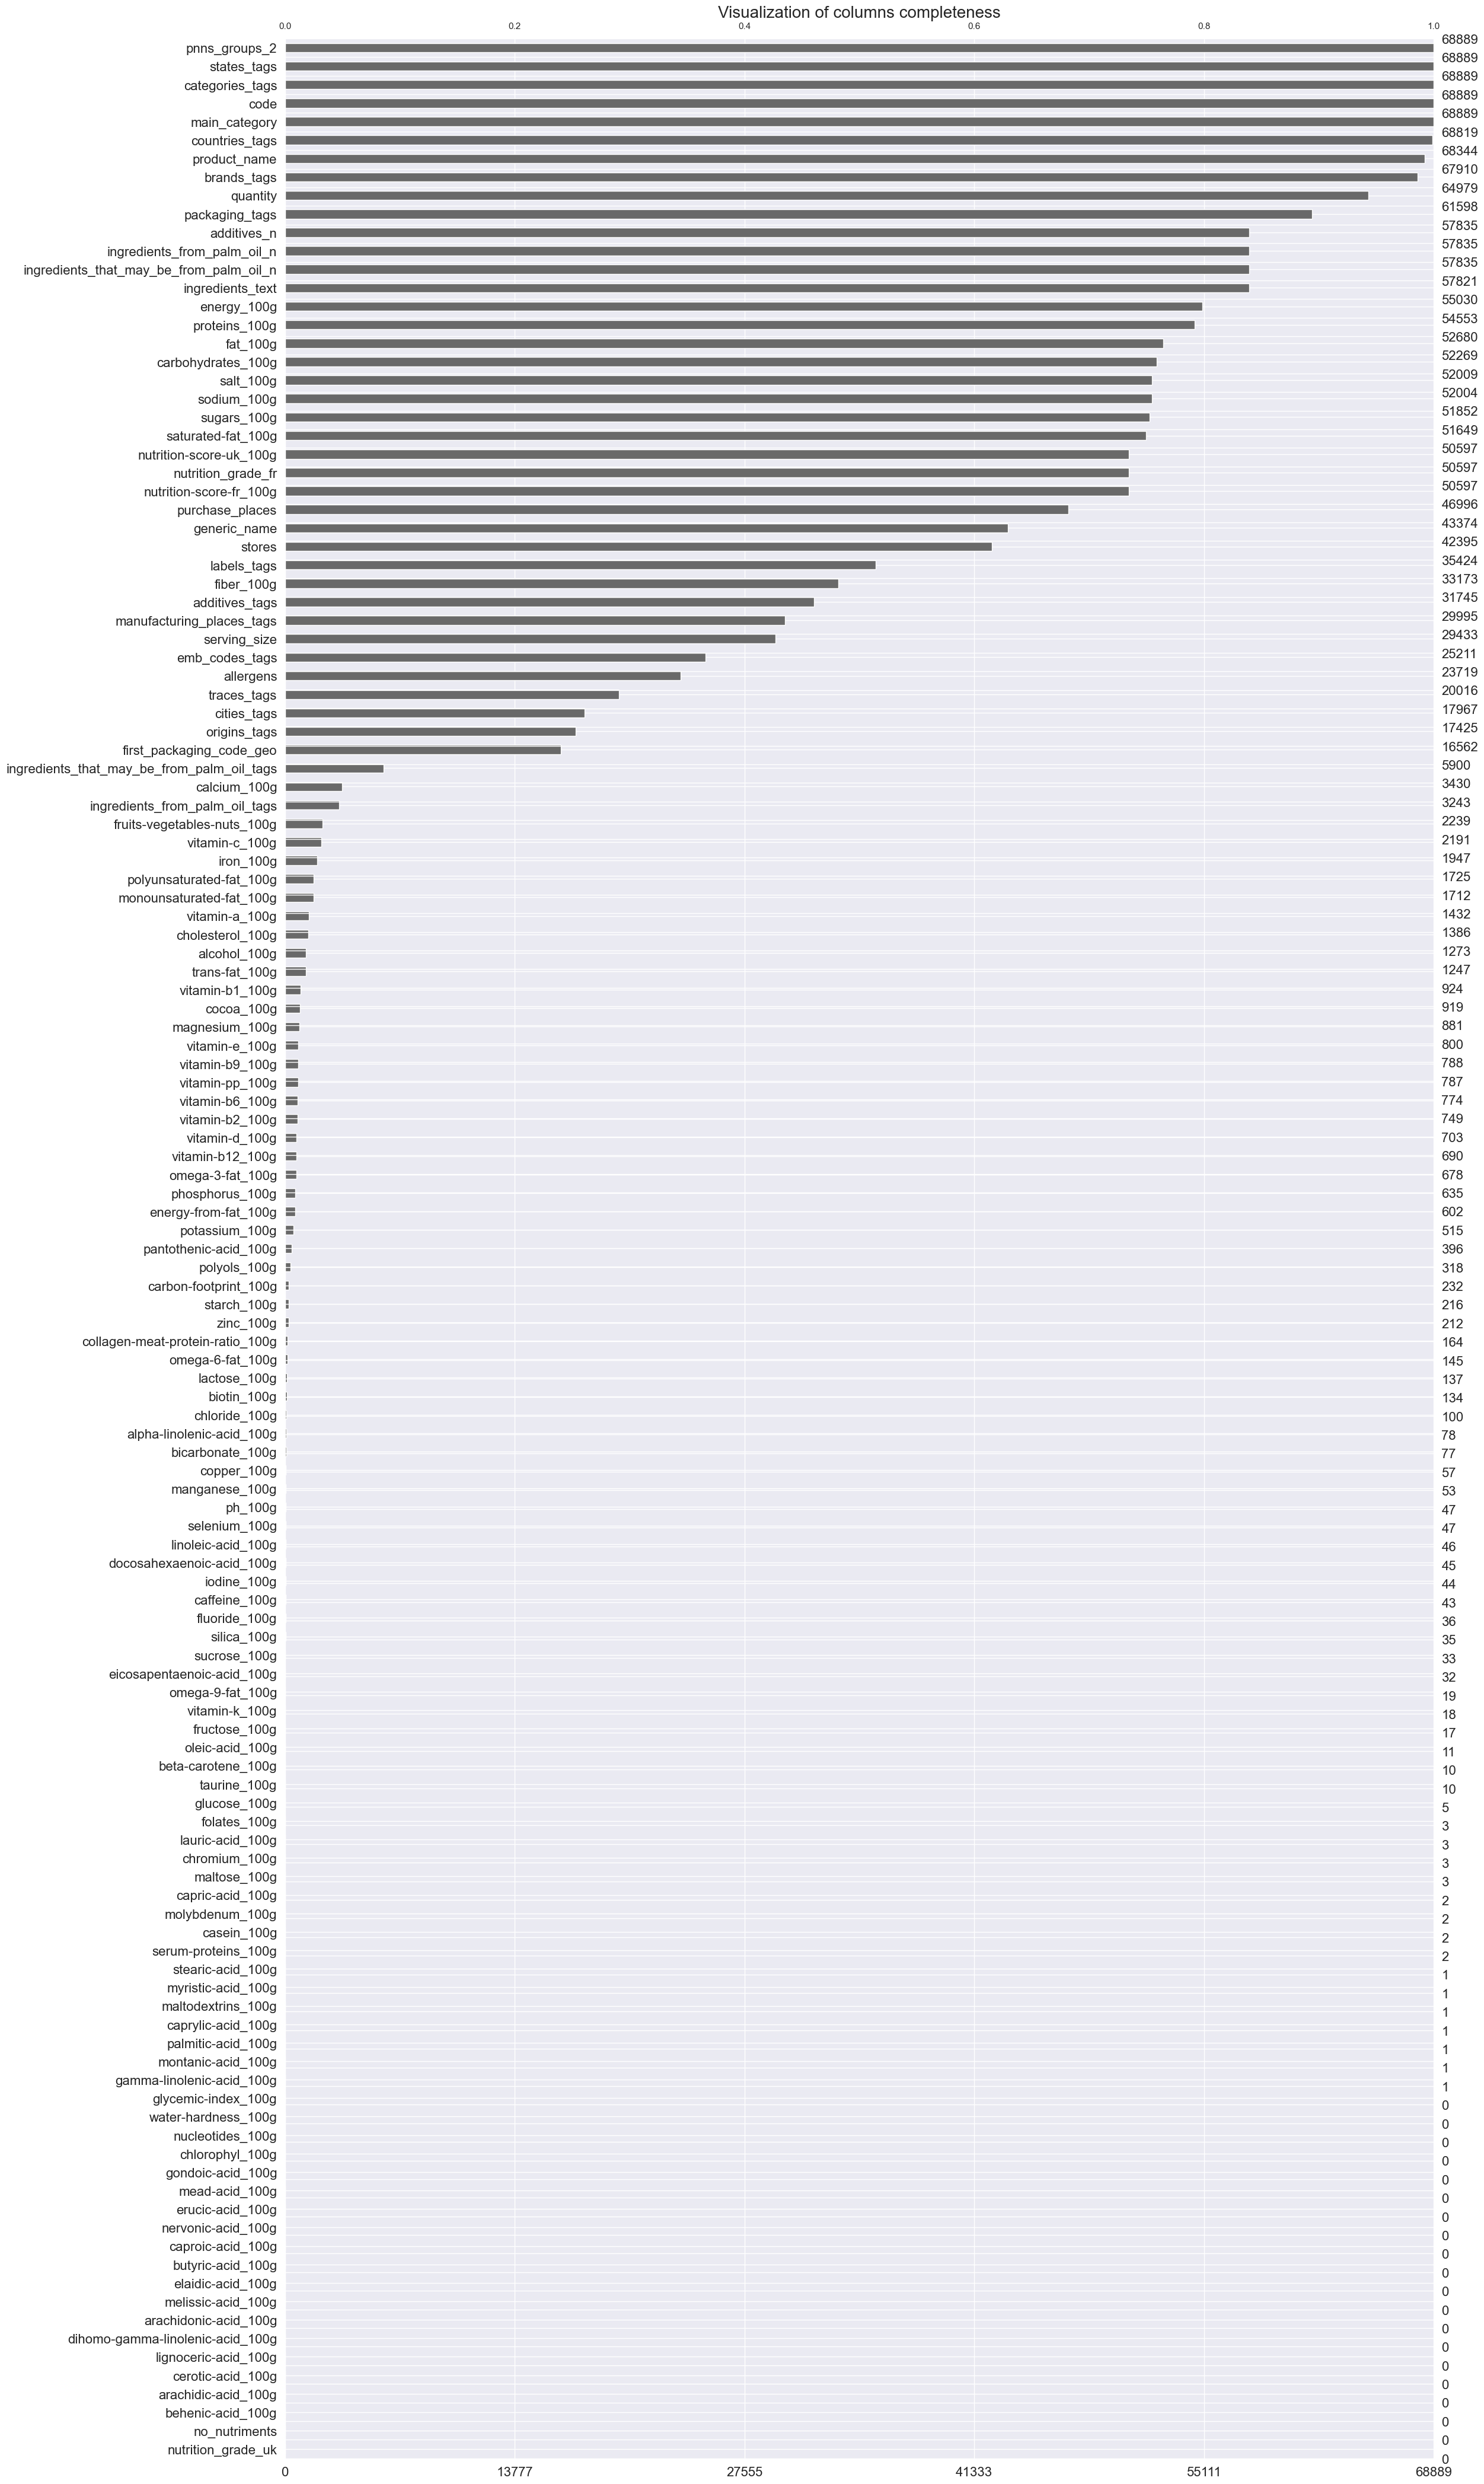

In [24]:
filtered_data = filter_to_keep_relevant_features(df=products, target="pnns_groups_1", visualize=True)

In [27]:
filtered_data_info = get_df_variables_info(filtered_data)

This DataFrame has 68886 rows and 29 columns.


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_3204\1951515332.py:36: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  modes = s.mode()


In [25]:
def splitString(s:str):
    splitted_s = s.split(':')
    if len(splitted_s) > 1:
        return splitted_s[1]
    else:
        return splitted_s[0]

def formatString(s:str):
    '''
    Parameters:
    s (str) : string to format

    Returns : The formatted string (only part after ":" kept, dashes replaced by whitespaces, numbers removed)
    '''
    s = s.replace('-', ' ')
    s = re.sub(r'\d', '', s)

    return s.strip()

In [26]:
# Apply a list of functions to transform the data
def transform_data(df:pd.DataFrame|pd.Series, funcs:list[Callable]):
    '''
    Applies a list of functions to transform the DataFrame.
    Parameters:
    df (pd.DataFrame): DataFrame to transform.
    funcs (list[Callable]): List of functions to apply to the DataFrame.
    Returns:
    pd.DataFrame: Transformed DataFrame.
    '''
    df_copy = df.copy()
    if funcs is not None and len(funcs) > 0:
        for f in funcs:
            try:
                # Iterate over numeric columns
                for col in df_copy.columns:
                    df_copy[col] = df_copy[col].apply(f)
            except AttributeError:
                df_copy = df_copy.progress_apply(f)
    return df_copy

In [27]:
def custom_transform(df:pd.DataFrame, col_to_transform:str, transforms:list[Callable], sep:str=None):
    if sep is None:
        raw_unique_values = df[col_to_transform].dropna().unique()
    else:
        raw_unique_values = df[col_to_transform].dropna().str.split(sep).explode().unique()
    
    result_df = pd.DataFrame({'initial':raw_unique_values}, columns=["initial", "transformed"])

    result_df["transformed"] = transform_data(result_df["initial"], transforms)

    return result_df

In [28]:
def getTranslated(s:str, timeout:Timeout=timeout):# translator:Translator=translator):
    translator = Translator(user_agent="DS_3", timeout=timeout)
    translated_text = translator.translate(s).text
    return translated_text

In [32]:
test = custom_transform(df=filtered_data, col_to_transform="packaging_tags", transforms=[getTranslated], sep= ",")

 40%|███▉      | 1386/3498 [12:41<19:19,  1.82it/s]  


KeyboardInterrupt: 

In [82]:
filtered_data_info

,column_type,missing_value_percentage,nbr_unique_values,nbr_null_values,nbr_non_null_values,duplicates_percentage,mode,min,max,mean,median,std,unique_values,additional_comment
additives_n,float64,16.046,26,11054,57835,99.96,0.0 (26090 occurrence(s)),0.0,31.000000,1.759817,1.00000,2.499738,too many to display,First 3 unique values represent 74.0% of total...
brands_tags,object,1.421,14385,979,67910,78.82,carrefour (2148 occurrence(s)),NaN,NaN,NaN,NaN,NaN,too many to display,None
carbohydrates_100g,float64,24.126,1557,16620,52269,97.02,0.0 (2371 occurrence(s)),0.0,190.000000,27.380236,13.80000,27.393096,too many to display,None
categories_tags,object,0.000,14752,0,68889,78.59,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...",NaN,NaN,NaN,NaN,NaN,too many to display,None
code,object,0.000,68886,0,68889,0.00,"11778, 14100097037, 41500007007 (2 occurrence(s))",NaN,NaN,NaN,NaN,NaN,too many to display,None
countries_tags,object,0.102,346,70,68819,99.50,France (48699 occurrence(s)),NaN,NaN,NaN,NaN,NaN,too many to display,None
energy_100g,float64,20.118,3561,13859,55030,93.53,3700.0 (238 occurrence(s)),0.0,22000.000000,1092.028355,992.00000,814.897824,too many to display,None
fat_100g,float64,23.529,1318,16209,52680,97.50,0.0 (4502 occurrence(s)),0.0,380.000000,13.552209,6.20000,17.747464,too many to display,None
generic_name,object,37.038,31511,25515,43374,27.35,Pâtes alimentaires au blé dur de qualité supér...,NaN,NaN,NaN,NaN,NaN,too many to display,None
ingredients_from_palm_oil_n,float64,16.046,3,11054,57835,99.99,0.0 (54592 occurrence(s)),0.0,2.000000,0.056903,0.00000,0.235215,"0.0 (54592 occurrences), 1.0 (3195 occurrences...",None


### Outliers detection and handling

#### Using logical value domain

Some variables have predetermined domain out of which values cannot be.  
For example all nutrients per 100g should be between 0g and 100g. 

In [29]:
exceptions = ["energy_100g", "nutrition-score-fr_100g", "nutrition-score-uk_100g"]
features_domain_0_100 = filtered_data.columns[filtered_data.columns.str.endswith("_100g") & ~filtered_data.columns.isin(exceptions)]

outliers_domain = filtered_data.loc[(filtered_data[features_domain_0_100] < 0).any(axis=1) | (filtered_data[features_domain_0_100] > 100).any(axis=1)]

with pd.option_context('display.max_columns', None):
    display(outliers_domain)

,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,countries_tags,ingredients_text,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,nutrition_grade_fr,pnns_groups_2,states_tags,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
111566,01364008,Tomato Ketchup,NaN,567 g,bottle,heinz,"en:groceries,en:sauces,en:tomato-sauces,en:ket...",NaN,"Chicago,Illinois,USA",7eleven,United Kingdom,"Tomato concentrate from red ripe tomatoes, dis...",0.0,0.0,0.0,d,Dressings and sauces,"en:to-be-checked,en:complete,en:nutrition-fact...",en:groceries,2510.0,0.588,0.588,136.0,134.0,7.06,0.01060,0.004170,17.0,17.0
176694,2000000045416,flake,flake,18g,plastic,NaN,"en:sugary-snacks,en:chocolates",NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,e,Chocolate products,"en:to-be-completed,en:nutrition-facts-complete...",en:chocolates,519.0,28.500,17.700,60.7,57.6,8.50,276.86000,109.000000,29.0,29.0
195738,3161712000928,Caprice des dieux,Fromage de France à pate molle,300g,"carton,carton",caprice-des-dieux,"en:dairies,en:cheeses,en:cow-cheeses",NaN,"Houilles,France",Leclerc,France,"_Lait_ de vache, _crème_, sel, ferments lactiq...",0.0,0.0,0.0,d,Cheese,"en:to-be-completed,en:nutrition-facts-complete...",en:cow-cheeses,1379.0,30.000,21.000,0.8,-0.1,15.30,1.40000,0.551181,15.0,20.0
232216,3423720002432,Keeny Bio,Moelleux au lait écrémé,135 g,paquet-individuel,bio-soleil,"en:sugary-snacks,en:biscuits-and-cakes,en:dess...","en:organic,en:eu-organic,en:palm-oil-free,fr:a...","Reims,France",Naturea,France,"Farine de _blé_ T65*, _Œufs_ entiers*, sucre d...",4.0,0.0,0.0,e,Biscuits and cakes,"en:to-be-completed,en:nutrition-facts-complete...",en:cakes,1720.0,23.000,3.330,47.8,26.7,6.30,211.00000,83.000000,22.0,22.0
234703,3473710080032,Palets pur beurre,Palets pur beurre,360 g,"plastique,metal",georges-blanc,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...","en:incorrect-data-on-label,en:incorrect-nutrit...",NaN,NaN,France,"Farine de _blé_, beurre frais de baratte (_lai...",2.0,0.0,0.0,e,Biscuits and cakes,"en:to-be-checked,en:complete,en:nutrition-fact...",en:biscuits,3925.0,52.000,35.500,106.0,52.0,10.00,1.30048,0.512000,31.0,31.0
239324,3560070740338,Sirop d'agave,NaN,250 ml,"flacon,plastique,flacon",carrefour-bio,"en:spreads,en:breakfasts,en:sweet-spreads,en:s...","en:organic,en:eu-organic,en:de-oko-001,fr:ab-a...","Lyon,France",Carrefour,France,Sirop d'agave concentré issu de l'agriculture ...,0.0,0.0,0.0,NaN,Sweets,"en:to-be-checked,en:complete,en:nutrition-fact...",en:sweet-spreads,1785.0,NaN,NaN,105.0,105.0,NaN,NaN,NaN,NaN,NaN
245288,3596710288755,mini choux goût fromage de chèvre - poivre,biscuits apéritifs,60 g,"etui-carton,film-plastique",auchan,"en:salty-snacks,en:appetizers,en:crackers,fr:p...",NaN,Tours,Simply market,France,matières grasses végétales de palme et de palm...,7.0,1.0,0.0,e,Appetizers,"en:to-be-completed,en:nutrition-facts-complete...",en:salty-snacks,18700.0,380.000,210.000,190.0,22.7,0.00,9.33000,3.670000,35.0,35.0
274744,5060224881163,Cheese salad,Cheese salad sandwhich,NaN,plastic-film,NaN,en:sandwiches,"en:incorrect-data-on-label,en:halal,en:incorre...","Kilburn,London,UK",Nisa,France,"torpido 69% (_Wheat_ flour, water, salt, yeast...",1.0,0.0,0.0,d,Sandwich,"en:to-be-completed,en:nutrition-facts-complete...",en:sandwiches,348.0,4.700,4.800,0.3,0.4,3.60,297.60000,117.165354,15.0,15.0
303078,8005305900255,Ekstra Jomfru Olivenolie,NaN,1L,NaN,santagata,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,Kvickly,Italy,NaN,NaN,NaN,NaN,d,Fats,"en:to-be-completed,en:nutrition-facts-complete...",en:olive-oils,3737.0,101.000,15.000,0.0,0.0,0.00,0.00000,0.000000,11.0,20.0
305031,8032942610032,Graine de couscous moyen,Semoule de couscous .,500g,boite-carton,la-mediterranea,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,

There are very few of those outliers and it is most likely due to human errors. Let's set the incoherent values to NaN for the moment.

In [30]:
filtered_data[features_domain_0_100] = filtered_data[features_domain_0_100].where((filtered_data[features_domain_0_100].values > 0) & (filtered_data[features_domain_0_100].values < 100), np.nan)

#### Using other logic

In [32]:
outliers_sugars_carbo_logic = filtered_data.loc[filtered_data["sugars_100g"] > filtered_data["carbohydrates_100g"]]
with pd.option_context('display.max_columns', None):
    display(outliers_sugars_carbo_logic)

,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,countries_tags,ingredients_text,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,nutrition_grade_fr,pnns_groups_2,states_tags,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
27505,318655,6 Pork & Bramley Apple Sausages,Saucisses d'origine britannique au porc britan...,400 g e,"frais,plastique,atmosphere-protectrice",marks-spencer,"en:meats,en:prepared-meats,en:sausages","en:gluten-free,en:incorrect-data-on-label,en:i...","Paris,France",Marks & Spencer Food,United States,Porc d'origine britannique élevé en plein air ...,3.0,0.0,0.0,d,Processed meat,"en:to-be-checked,en:complete,en:nutrition-fact...",en:sausages,1023.0,19.2,7.00,5.50,5.60,12.40,1.18000,0.464567,14.0,14.0
66912,60383998622,Milk chocolate with hazelnuts,milk chocolate,300 g,paper,"pc,president-s-choice","en:sugary-snacks,en:chocolates","en:incorrect-data-on-label,en:incorrect-nutrit...",NaN,NaN,United States,"sugar, milk powder, hazelnuts, cocoa butter, u...",1.0,0.0,0.0,e,Chocolate products,"en:to-be-checked,en:complete,en:nutrition-fact...",en:chocolates,2420.0,36.8,15.80,52.60,76.30,7.89,0.20100,0.078900,22.0,22.0
67359,63351049005,Rôti de bœuf au jus,"Viande de boeuf cuisinée, entièrement cuit",1 kg,refrigerer-et-a-garder-au-froid,cardinal,"en:meals,en:meals-with-meat,en:beef-dishes,en:...","en:incorrect-data-on-label,en:incorrect-nutrit...","Brossard,Québec",Costco,Singapore,"RÔTI DE BŒUF ANGUS. SAUCE AU JUS: EAU, SEL, P...",1.0,0.0,0.0,b,One-dish meals,"en:to-be-checked,en:complete,en:nutrition-fact...",en:meals-with-meat,502.0,5.0,2.00,1.00,2.00,18.00,0.94000,0.370000,1.0,1.0
174058,898999000022,Vita coco,NaN,NaN,NaN,"vita-coco,all-market-inc","en:beverages,en:non-sugared-beverages",NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,d,Non-sugared beverages,"en:to-be-completed,en:nutrition-facts-complete...",en:beverages,75.0,NaN,NaN,4.55,5.00,NaN,0.02000,0.007874,7.0,1.0
178305,20158125,Fromage blanc saveur vanille,NaN,800 g,"pots,plastique",milbona,"en:dairies,en:cheeses,fr:fromages-blancs",NaN,France,NaN,France,Fromage blanc 20% de Mat. Gr. (lait écrémé pas...,5.0,0.0,1.0,b,Cheese,"en:to-be-checked,en:complete,en:nutrition-fact...",fr:fromages-blancs,406.0,2.2,1.50,13.00,14.00,5.40,0.08000,0.031496,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312040,8480017537188,Filets d'anchois à l'huile d'olive,Filets d'anchois,100 g,pot-de-verre,dia,"en:canned-foods,en:seafood,en:fishes,en:canned...","en:incorrect-data-on-label,en:incorrect-nutrit...","Bollène,France",Dia,France,"Filets d'anchois salés 60%, (anchois, sel), hu...",0.0,0.0,0.0,d,Fish and seafood,"en:to-be-checked,en:complete,en:nutrition-fact...",en:canned-fishes,825.0,11.0,3.20,1.60,2.00,23.00,15.72000,6.188976,15.0,15.0
315457,8718114712277,Ben & Jerry's - Fairly Nuts,"Crème glacée Caramel, sauce caramel (9%) et de...","500 mL, 426g",surgele,ben-jerry-s,"en:desserts,en:frozen-foods,en:frozen-desserts...","en:fair-trade,en:fairtrade-international",NaN,NaN,France,"Crème (27%), eau, lait concentré écrémé, sucre...",5.0,0.0,0.0,d,Ice cream,"en:to-be-checked,en:complete,en:nutrition-fact...",en:ice-creams,1172.0,15.0,11.00,23.00,26.00,4.00,0.21000,0.082677,18.0,18.0
316798,8850539240390,Prik Khing Curry Paste,NaN,114g,canned,maesri,"en:groceries,en:sauces,en:curry-pastes","en:incorrect-data-on-label,en:no-preservatives...","Sydney,NSW,Australia","Thai Kee Supermarket,Asian Supermarkets",France,"Dried Red Chilli, Garlic, Shallot, Lemon Grass...",0.0,0.0,0.0,d,Dressings and sauces,"en:to-be-checked,en:complete,en:nutrition-fact...",en:groceries,398.0,1.9,0.26,11.89,12.56,3.52,7.96798,3.137000,13.0,13.0
318938,9300624407621,Deep Spring Orange & Passionfruit,NaN,1.25L,pla

In [31]:
filtered_data.loc[filtered_data["sugars_100g"] > filtered_data["carbohydrates_100g"], "sugars_100g"] = filtered_data["carbohydrates_100g"]

In [32]:
macros_nutrients = ["carbohydrates_100g", "proteins_100g", "fat_100g"]
outliers_sum_macros_logic = filtered_data.loc[filtered_data[macros_nutrients].sum(axis=1) > 103] # 103 instead of 100 because it seems nutrients can be rounded up to the next integer
outliers_sum_macros_logic

,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
35205,38000391224,Froot Loops,NaN,NaN,box,kellogg-s,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,NaN,...,1590.0,3.450,1.72,86.20,34.50,34.50,1.31000,0.517000,12.0,12.0
57349,44738209618,Coconut Milk Powder,Coconut Milk Powder,70 g,canned,"chaokoh,thep-padung-porn-coconut-co","en:plant-based-foods-and-beverages,en:beverage...",en:halal,"Virginia Beach,Virginia,United States",NaN,...,3180.0,60.000,44.00,32.00,12.00,12.00,0.14200,0.056000,21.0,21.0
95749,780117,Spaghetti,Organic Pasta Imported From Italy,16 OZ (1 LB) 454 g,NaN,trader-giotto-s,"en:plant-based-foods-and-beverages,en:plant-ba...","en:organic,en:usda-organic",NaN,NaN,...,1570.0,17.900,NaN,76.80,5.36,10.70,NaN,NaN,NaN,NaN
96592,78742038520,Flavored Chocolate Chip Cookies - Soft Baked,Chocolate chip cookies,8.9 oz (252g),plastic,"price-first,wal-mart-stores-inc","en:sugary-snacks,en:biscuits-and-cakes,en:bisc...","en:kosher,en:orthodox-union-kosher,en:d",United States,NaN,...,2190.0,21.400,7.14,81.00,38.10,4.76,2.06000,0.810000,29.0,29.0
167184,859888000332,Sweet Crunch Sprouted Cookies,NaN,NaN,NaN,"go-raw,freeland-foods","en:sugary-snacks,en:biscuits-and-cakes,en:bisc...","en:organic,en:no-gmos,en:no-milk","Santa Monica,California,USA",Whole Foods Market,...,2389.0,32.140,17.86,64.29,39.29,7.14,0.09144,0.036000,20.0,20.0
180099,20481957,Blanc Coco Céréales,Chocolat blanc à la noix de coco râpée et aux ...,200 g,carton,bellarom,"en:sugary-snacks,en:chocolates,en:white-chocol...","en:sustainable-farming,en:fsc,en:utz-certified","Lyon,France",Lidl,...,2534.0,38.200,27.10,59.30,41.80,5.80,1.24460,0.490000,29.0,29.0
186800,29061112,Eisfix Kakao,Kakaohaltige Fettglasur,225ml,"kuststoff,01-pet",mucci,"en:groceries,en:sauces","en:sustainable-farming,en:utz-certified,en:gre...",NaN,NaN,...,3018.0,58.500,27.20,45.00,43.90,3.30,0.10000,0.039370,28.0,28.0
186936,2952350335784,Biscuit cru The Matcha - Fleur de coco,NaN,NaN,NaN,happy-crackers,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...","en:organic,en:eu-organic,fr:ab-agriculture-bio...",NaN,NaN,...,1607.0,12.800,9.50,99.30,27.90,6.50,0.02000,0.007874,14.0,14.0
192001,3068236309998,Pâte d'amandes tricolore,NaN,250 g,"plastique,sachet",sun,"en:sugary-snacks,en:confectioneries,en:christm...",NaN,"France,Noyelles-Godault",Auchan,...,1644.0,26.000,1.00,76.00,67.00,6.00,0.02000,0.007874,14.0,14.0
196613,3168930008163,Saveur Fromage,Chips de Pommes de terre goût fromage,130g,"sachet,plastique,sous-atmosphere-protectrice",lay-s,"en:salty-snacks,en:appetizers,en:chips-and-fri...","en:no-colorings,en:no-artificial-colors,en:pal...",NaN,NaN,...,2214.0,33.000,3.80,82.00,3.00,6.30,1.90000,0.748031,12.0,12.0


In [33]:
filtered_data.loc[filtered_data[macros_nutrients].sum(axis=1) > 103, macros_nutrients] = np.nan

In [34]:
outliers_satfat_fat_logic = filtered_data.loc[filtered_data["saturated-fat_100g"] > filtered_data["fat_100g"]]
outliers_satfat_fat_logic

,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
177333,20031244,Macarons de coco,NaN,350 g (5 pièces),sachet-plastique,sondey,"en:sugary-snacks,en:biscuits-and-cakes,en:dess...",NaN,"Gap,05000,France",Lidl,...,1990.0,23.000,23.100,60.0,48.0000,4.50,0.2000,0.078740,25.0,25.0
185447,26107851,Vegetable Medley Tub,NaN,300g Frozen,plastic-tub,"market-fare,aldi","en:plant-based-foods-and-beverages,en:plant-ba...","en:heart-foundation-tick,en:suitable-for-veget...","NSW,Australia",Aldi,...,127.0,0.400,1.000,4.0,2.3000,1.70,0.0762,0.030000,-8.0,-8.0
193841,3103220009956,Tirlibibi,Confiserie assortie,500g,plastique,haribo,"en:sugary-snacks,en:confectioneries,en:candies",NaN,NaN,NaN,...,1448.0,0.600,0.800,79.0,50.0000,4.40,0.5500,0.216535,16.0,16.0
193852,3103220021422,Happé box,NaN,"1,1 kg","boite,plastique",haribo,"en:sugary-snacks,en:confectioneries,en:candies",NaN,NaN,NaN,...,1460.0,0.600,0.800,79.0,50.0000,4.40,0.5500,0.216535,16.0,16.0
197918,3178530405996,Goûters fourrés au chocolat,NaN,225 g,carton,banania,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...",NaN,"Vénissieux,France",Carrefour,...,2066.0,12.000,12.500,66.0,37.0000,6.00,0.5000,0.196850,22.0,22.0
202607,3229820790824,Sauce Yakitori,"Assaisonnement à base de sauce soja, de sucre ...",230 g,"verre,bouteille",tanoshi,"en:groceries,en:condiments,en:sauces,en:soy-sa...",en:green-dot,"France,Nantes",Leclerc,...,769.0,0.100,0.500,42.2,33.0000,2.80,6.8000,2.677165,19.0,19.0
205655,3250390491064,Notre Ratatouille Cuisinée et ses tomates séchées,Mélange de légumes cuisinés,"600 g , 660 ml","bocal,verre,couvercle,metal,conserve",saint-eloi,"en:canned-foods,en:meals,en:prepared-vegetable...","en:labels-of-distributors,en:green-dot,fr:sele...",France,Intermarché,...,1544.0,4.000,12.000,7.5,2.0600,1.50,2.0000,0.787402,20.0,20.0
205728,3250390600671,Adelie Bac Vanille,NaN,NaN,NaN,adelie,"en:desserts,en:frozen-foods,en:frozen-desserts...","en:labels-of-distributors,fr:selection-interma...",NaN,NaN,...,812.0,8.900,15.800,25.7,25.7000,2.10,0.2200,0.086614,22.0,22.0
206136,3250391072781,Léger Doux,Matière grasse légère à tartiner à 20% de mati...,250 g e,"frais,plastique,barquette",netto,"en:spreads,en:dairies,en:fats,en:spreadable-fa...",NaN,"France,Nantes",Netto,...,878.0,20.000,23.000,8.1,2.5000,0.50,0.5000,0.196850,14.0,14.0
206293,3250391162307,Salsa Medium,Sauce épicée aux tomates et aux poivrons,315 g,"pot,verre",saveur-du-mexique,"en:groceries,en:sauces,en:dips,fr:sauces-epicees",NaN,"Paris,France",NaN,...,197.0,0.200,0.500,9.5,8.9000,6.40,1.7400,0.685039,5.0,5.0


In [35]:
filtered_data.loc[filtered_data["saturated-fat_100g"] > filtered_data["fat_100g"], "saturated-fat_100g"] = filtered_data["fat_100g"]

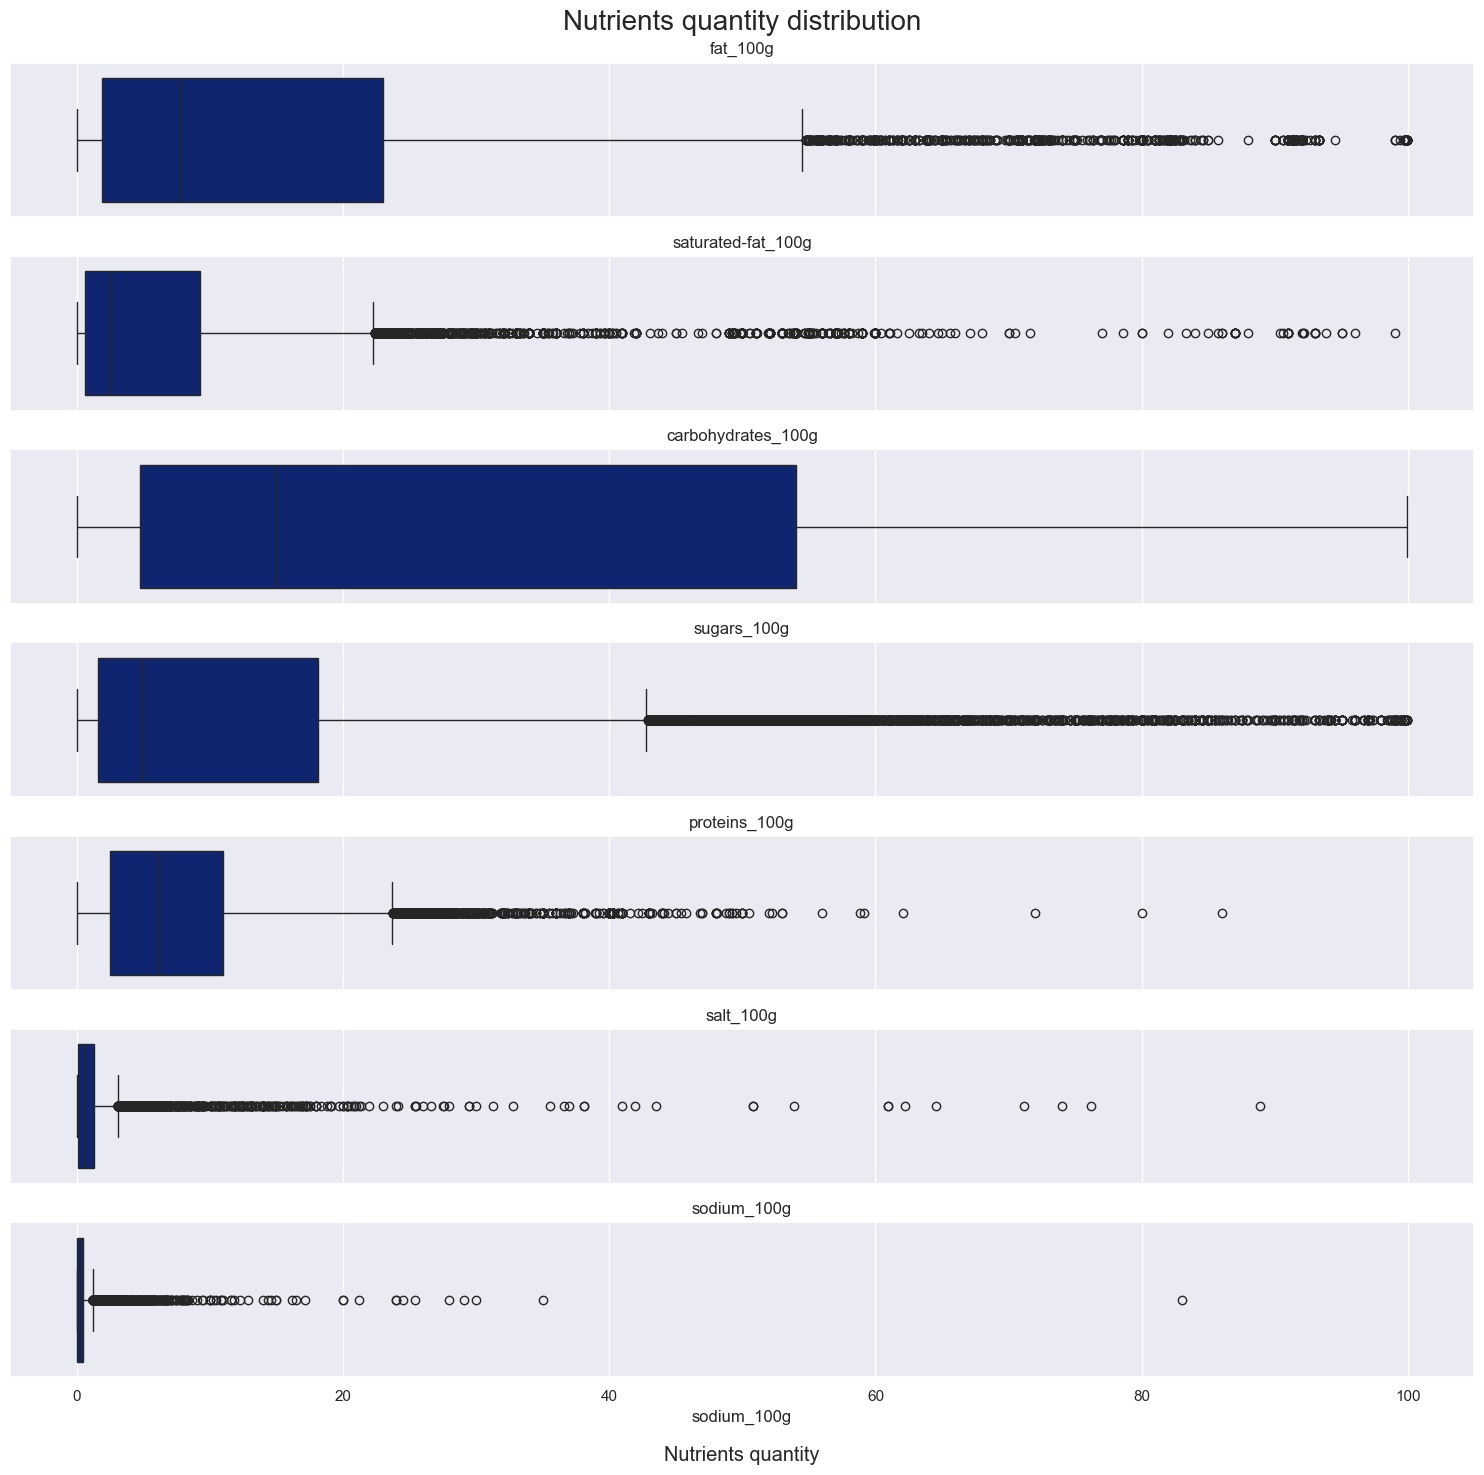

In [40]:
fig, axes = plt.subplots(len(features_domain_0_100), sharex=True, figsize=(15,15))

for i, col in enumerate(features_domain_0_100):
    sns.boxplot(data=filtered_data, x=col, ax=axes[i])
    axes[i].set_title(col)
fig.suptitle("Nutrients quantity distribution", fontsize=20)
fig.supxlabel("Nutrients quantity")
fig.tight_layout()

In [36]:
def eta_squared(x,y):
    '''
    Calculates the eta-squared statistic, a measure of effect size for categorical variables.

    Parameters:
    x (array-like): Categorical variable.
    y (array-like): Continuous variable.

    Returns:
    float: Eta-squared value representing the proportion of variance in y explained by x.
    '''
    y = y.dropna()
    moyenne_y = y.mean()
    classes = []
    for classe in x.dropna().unique():
        yi_classe = y[x==classe]
        if len(yi_classe) > 0:
            classes.append({'ni': len(yi_classe),
                            'moyenne_classe': yi_classe.mean()})
    
    SCT = sum([(yj-moyenne_y)**2 for yj in y])
    SCE = sum([c['ni']*(c['moyenne_classe']-moyenne_y)**2 for c in classes])

    return SCE/SCT

In [37]:
def ANOVA(df, x:str, y:str, plot_function:Callable=sns.violinplot, transforms:Optional[list[Callable]]=None, **plot_params):
    '''
    Performs ANOVA analysis and visualizes the results using a specified plotting function.

    Parameters:
    df (pd.DataFrame): DataFrame containing the data.
    x (str): Categorical variable for grouping.
    y (str): Continuous variable for analysis.
    countries: List of countries to filter.
    inds: List of indicators to include.
    year: Year for filtering data.
    plot_function (Callable): Function for plotting results. Defaults to sns.violinplot.
    **plot_params: Additional parameters for the plotting function.

    Returns:
    None: Displays the plot with eta-squared value annotated.
    '''

    pivoted_df = df.loc[df[x] != "Undefined"]

    transformed_df = transform_data(pivoted_df, funcs=transforms)

    eta = round(eta_squared(transformed_df[x],transformed_df[y]), 2)

    fig, ax = plt.subplots(figsize=(20,5))
    plot_function(transformed_df, ax=ax, x=x, y=y, **plot_params)
    corr_test = AnchoredText(f"η² = {eta}", loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.add_artist(corr_test)
    counts_by_x = filtered_data.loc[filtered_data[y].notna()].value_counts(x)
    for group in counts_by_x.index:
        ax.text(x=group, y=105, s=counts_by_x[group], fontsize=5)
    plt.plot()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_168\1664979686.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


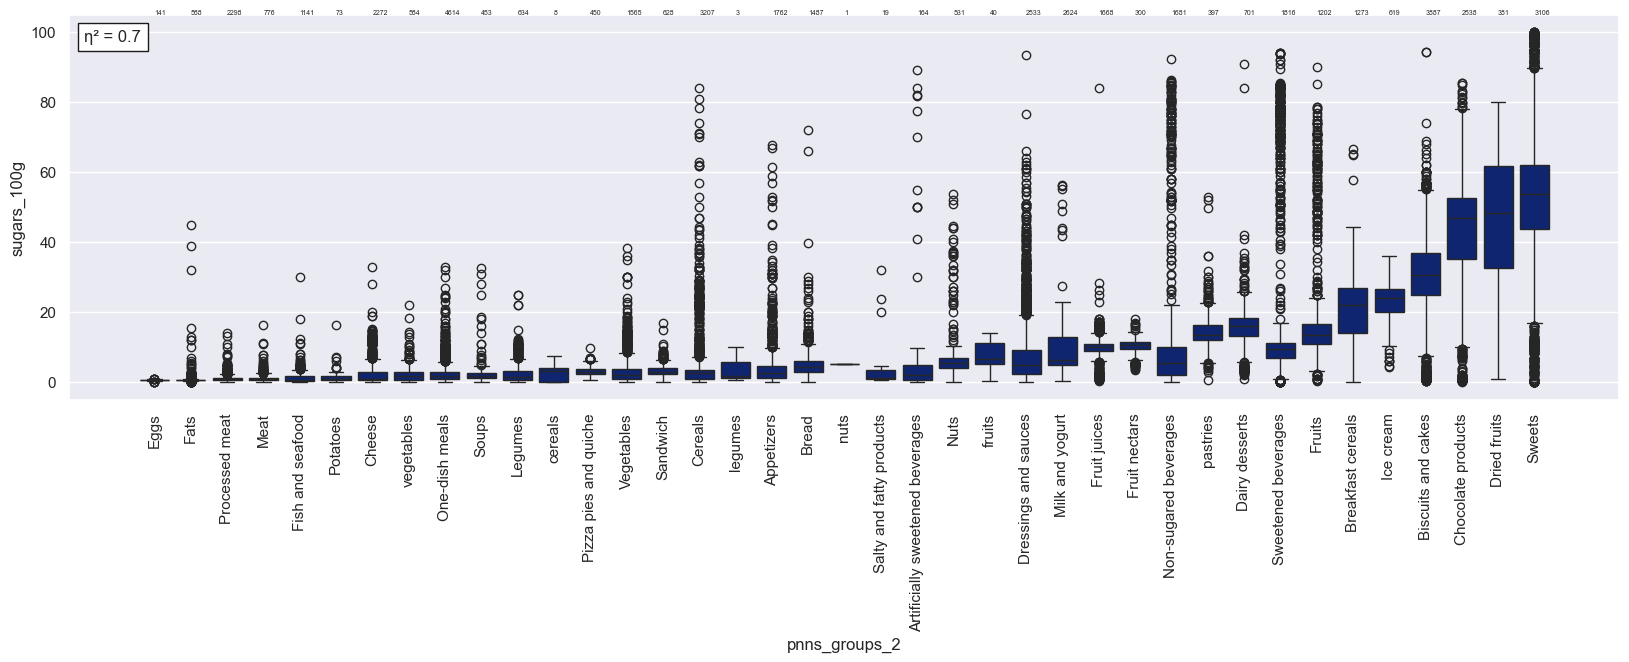

In [42]:
ANOVA(filtered_data, x="pnns_groups_2", y="sugars_100g", plot_function=sns.boxplot, order=filtered_data["sugars_100g"].groupby(filtered_data["pnns_groups_2"]).mean().sort_values().index)

In [47]:
filtered_data.loc[(filtered_data["sugars_100g"] > 40) & (filtered_data["pnns_groups_2"] == "Non-sugared beverages")]

,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,...,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
97331,78742074177,"Low Calorie Drink Mix, Blueberry Berry Splash",NaN,NaN,NaN,great-value,"en:beverages,en:non-sugared-beverages",NaN,NaN,NaN,...,1393.0,NaN,NaN,88.89,66.67,NaN,1.12776,0.444000,24.0,18.0
99741,79800042015,Guava Syrup,NaN,15.75 oz (446 g),NaN,hawaiian-sun,"en:beverages,en:syrups,en:flavoured-syrups,en:...",NaN,NaN,NaN,...,1240.0,NaN,NaN,73.00,70.30,NaN,0.03430,0.013500,20.0,13.0
122553,658564703983,Elephant Vanilla Chai,Gewürzteemischung mit Schwarzteepulver und Gew...,398 g,"karton,aluminium",david-rio,"en:beverages,en:hot-beverages,en:instant-hot-b...","en:no-gmos,en:no-lactose",NaN,NaN,...,1820.0,12.1,6.43,75.00,64.30,2.86,0.10700,0.042200,26.0,21.0
176458,2000000036204,Sagylait,Lait en poudre demi-écrémé,15 g,sachet,sagy,"en:beverages,en:dairies,en:dried-products,en:m...","en:green-dot,fr:origine-france,fr:qualite-premium","France,Haguenau,Rennes,Vannes","RCIR,Armée de Terre",...,1810.0,14.0,9.00,45.00,45.00,31.00,0.92000,0.362205,NaN,NaN
177179,20020392,Sirop de grenadine,NaN,750 ml (985 g),"bouteille,metal","plein-sud,lidl","en:beverages,en:syrups,en:flavoured-syrups,en:...","en:no-colorings,en:no-preservatives,en:green-dot",NaN,NaN,...,1428.0,0.1,0.10,84.00,80.00,0.10,0.30000,0.118110,21.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313896,8711544990642,Dixap appel,Geconcentreerd appelsap,500ml,"groene-glazen-fles,plastic-dop,glasbak",covelt,"en:beverages,en:syrups,en:flavoured-syrups,en:...",NaN,Nederland,NaN,...,1457.0,NaN,NaN,85.70,85.70,0.50,0.50000,0.196850,12.0,11.0
313938,8711812407285,20 Kruiden oplosthee,20 kruiden oplosthee,200 g,NaN,zonnatura,"en:plant-based-foods-and-beverages,en:beverage...",NaN,Netherlands,NaN,...,1552.0,1.0,NaN,92.60,92.20,0.10,0.10000,0.039370,NaN,NaN
315022,8714200214519,Salmiakrondo's,NaN,265 g,NaN,venco,"en:plant-based-foods-and-beverages,en:beverage...",NaN,NaN,NaN,...,1600.0,1.2,1.10,92.00,76.00,0.10,0.12000,0.047244,21.0,15.0
315682,8718692612129,Concentré saveur Limonade Rose,NaN,500 ml,plastique,sodastream,"en:beverages,en:artificially-sweetened-beverag...","en:kosher,en:no-artificial-colors,en:no-artifi...","Courrières,France",Cora,...,1258.0,NaN,NaN,74.00,74.00,NaN,0.20000,0.078740,20.0,13.0


In [38]:
def coef_var(values:pd.Series):
    values = values.dropna()
    if (len(values) > 20):
        mean = np.mean(values)
        if mean == 0:
            return 0
        cv = np.std(values)/abs(mean)
        if (cv < 0.3):
            return cv
    return np.nan

def method_if_criteria_met(values:pd.Series, method:Callable):
    values = values.dropna()
    if (len(values) > 20):
        mean = np.mean(values)
        if mean == 0:
            return 0
        if (np.std(values)/abs(mean) < 0.3):
            return method(values)
    return np.nan

<Axes: >

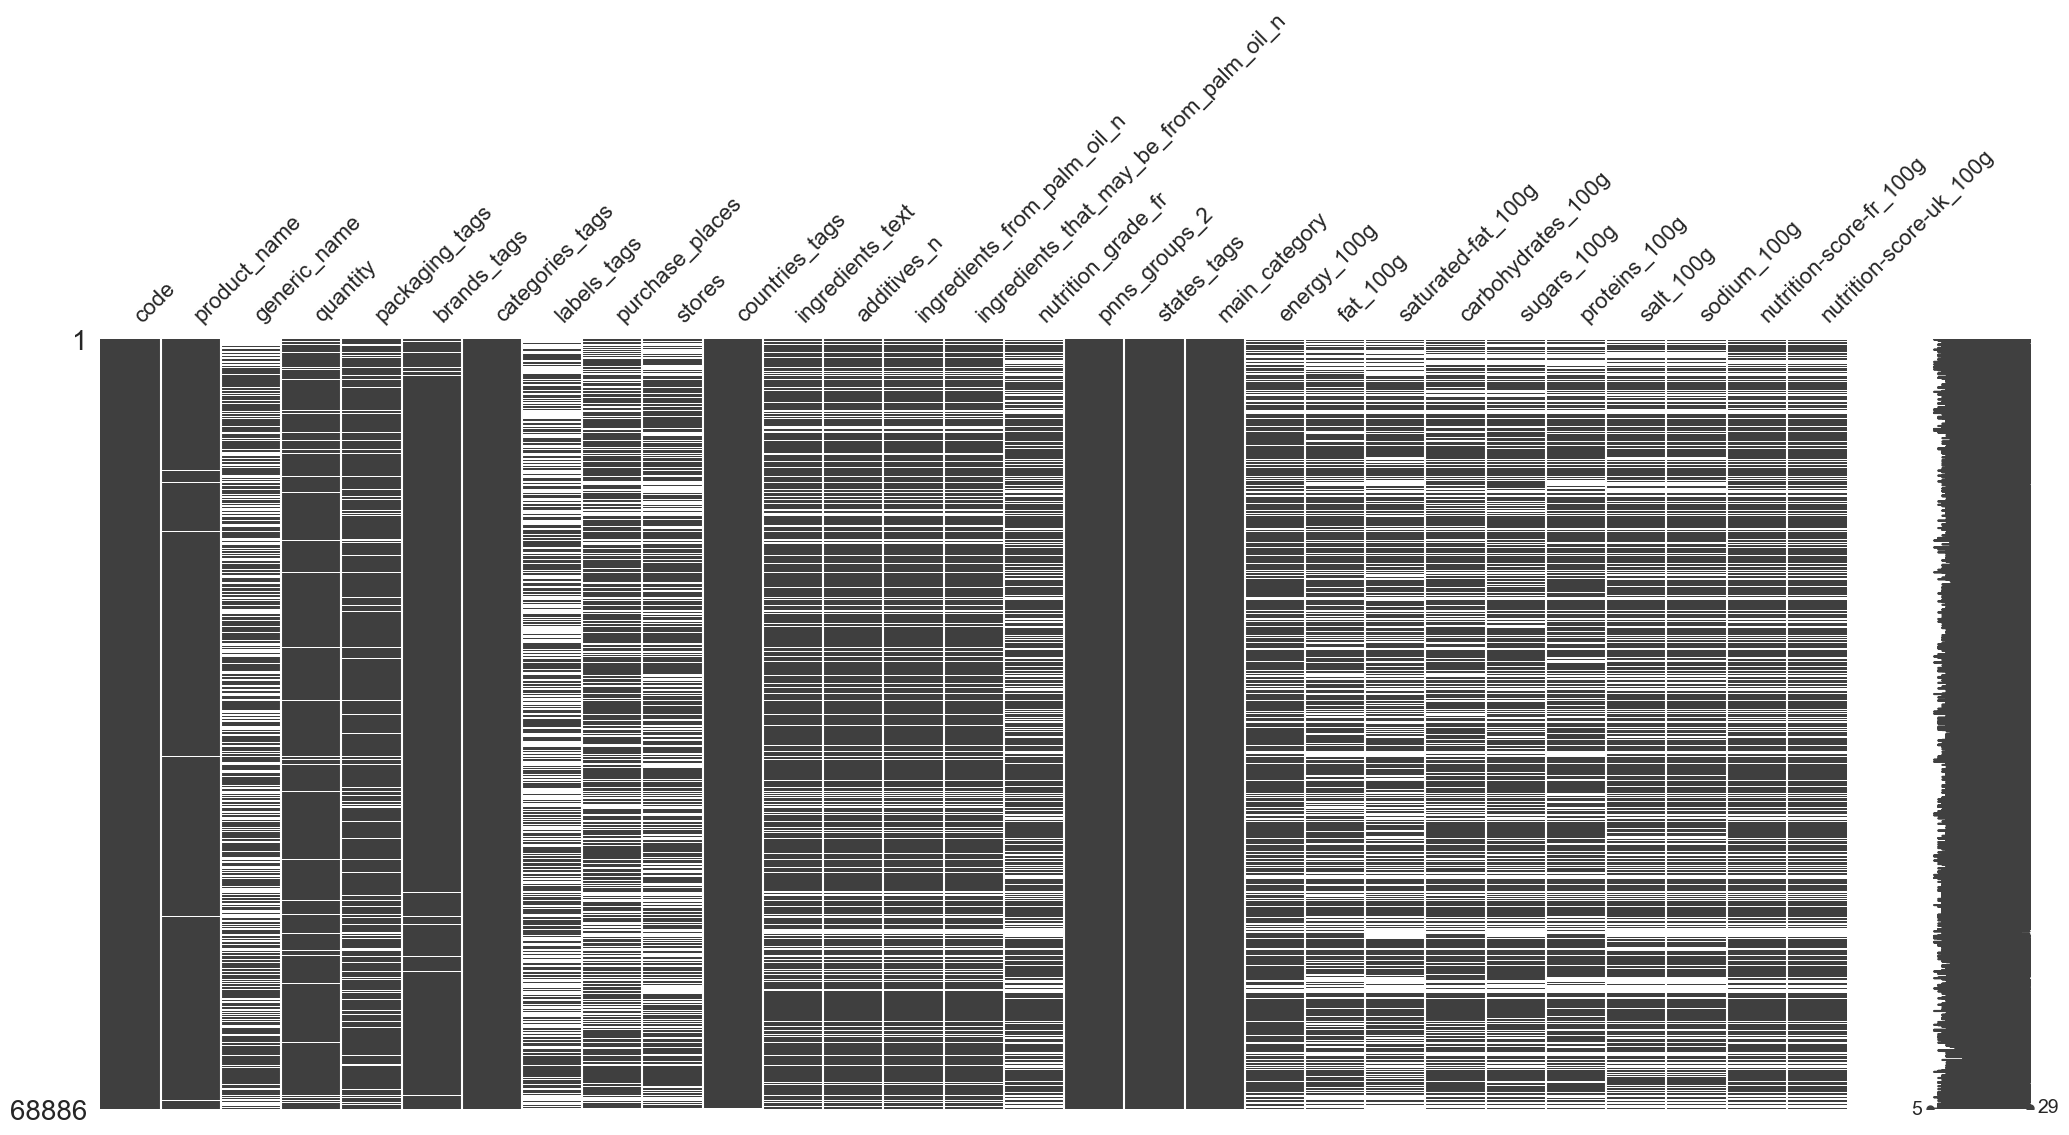

In [40]:
msno.matrix(df=filtered_data)

<Axes: >

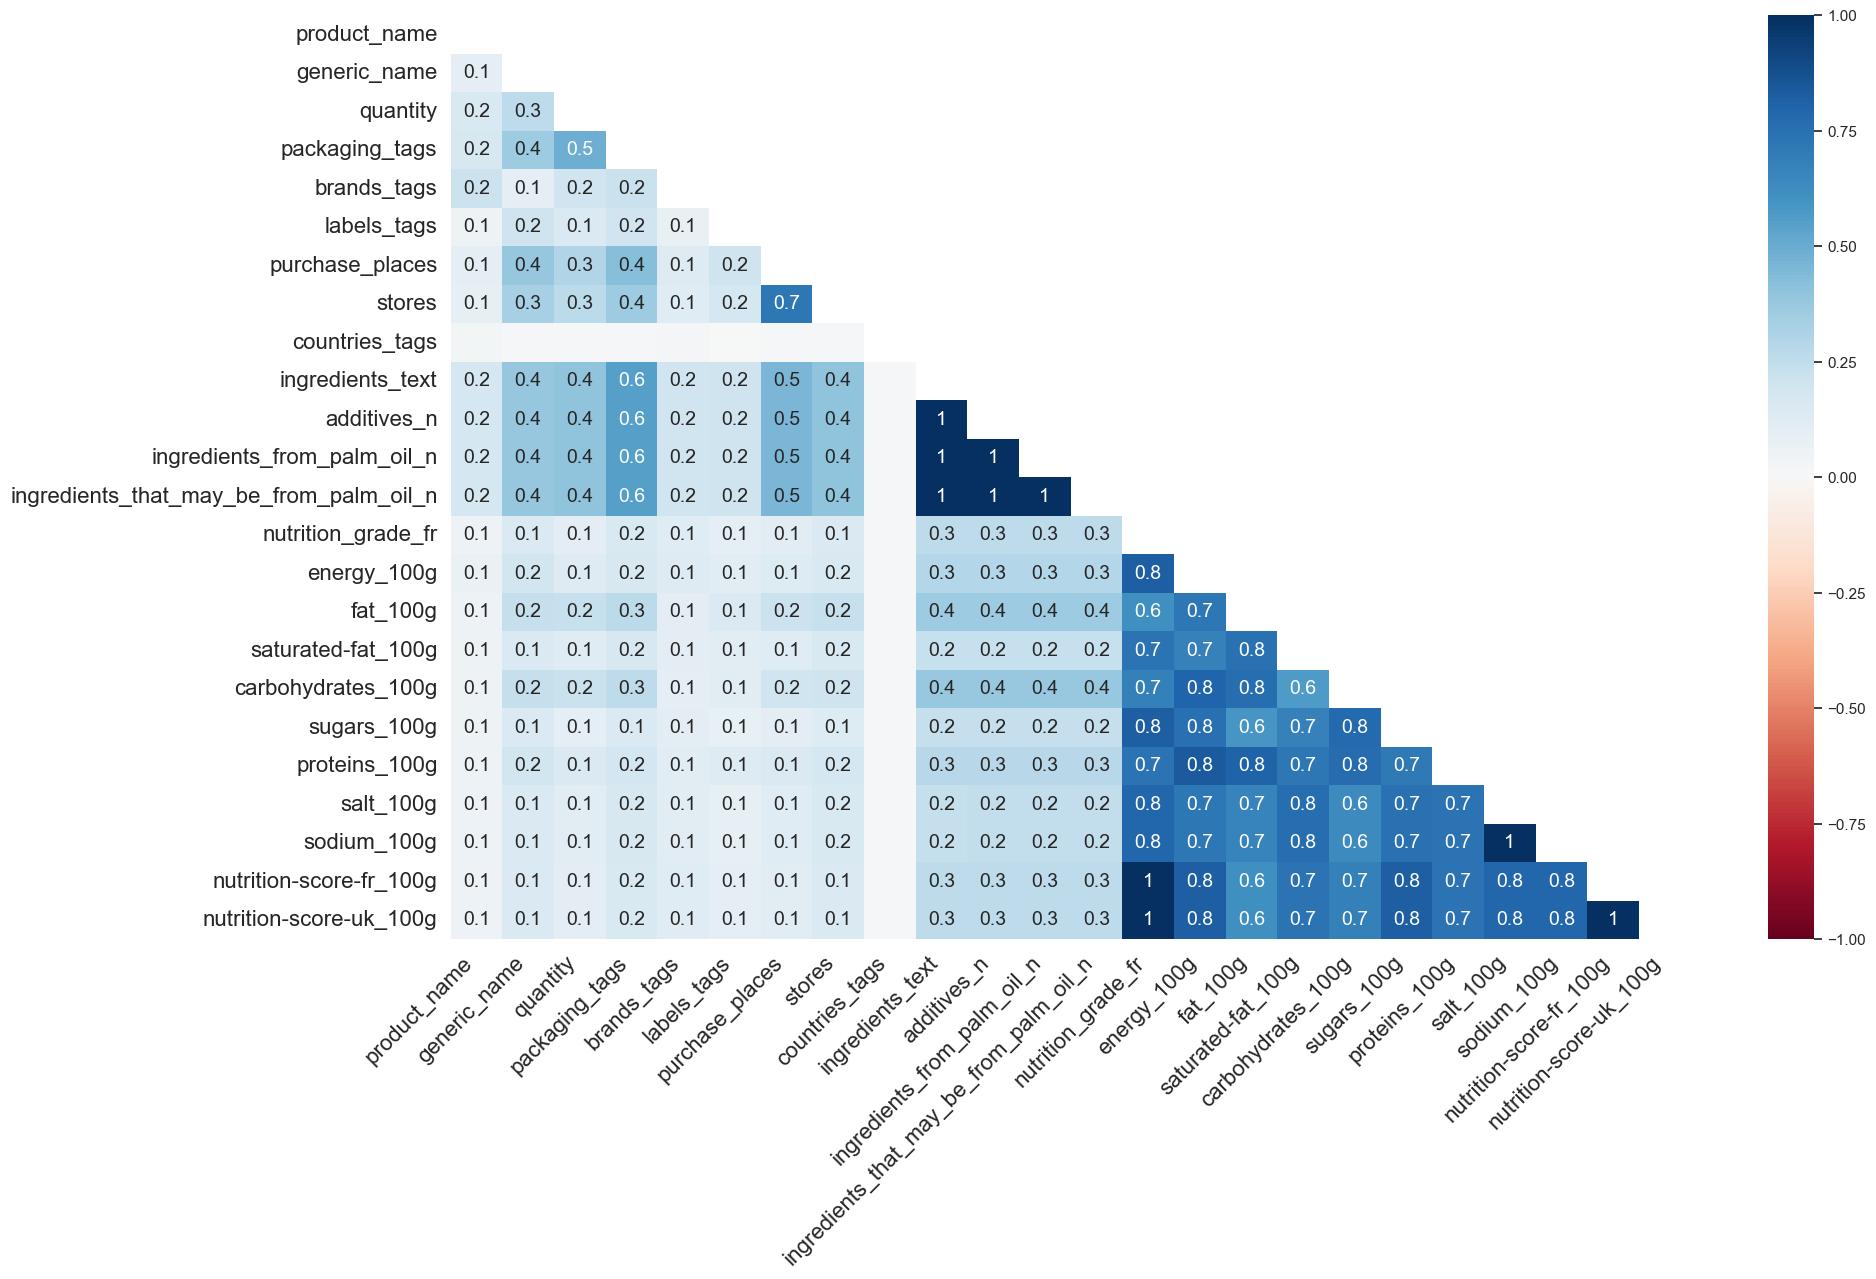

In [41]:
msno.heatmap(df=filtered_data)

In [55]:
def draw_heatmap(corr_matrix:pd.DataFrame, **plot_params):
    '''
    Draws a heatmap for the given correlation matrix.

    Parameters:
    corr_matrix (pd.DataFrame): Correlation matrix to visualize.
    '''
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    fig, ax = plt.subplots(figsize=(15, 10))
    ax = sns.heatmap(corr_matrix, ax=ax, mask=mask, center=0, **plot_params)
    ax.set_title("Correlation matrix (random sample of 100 indicators)")
    plt.plot()

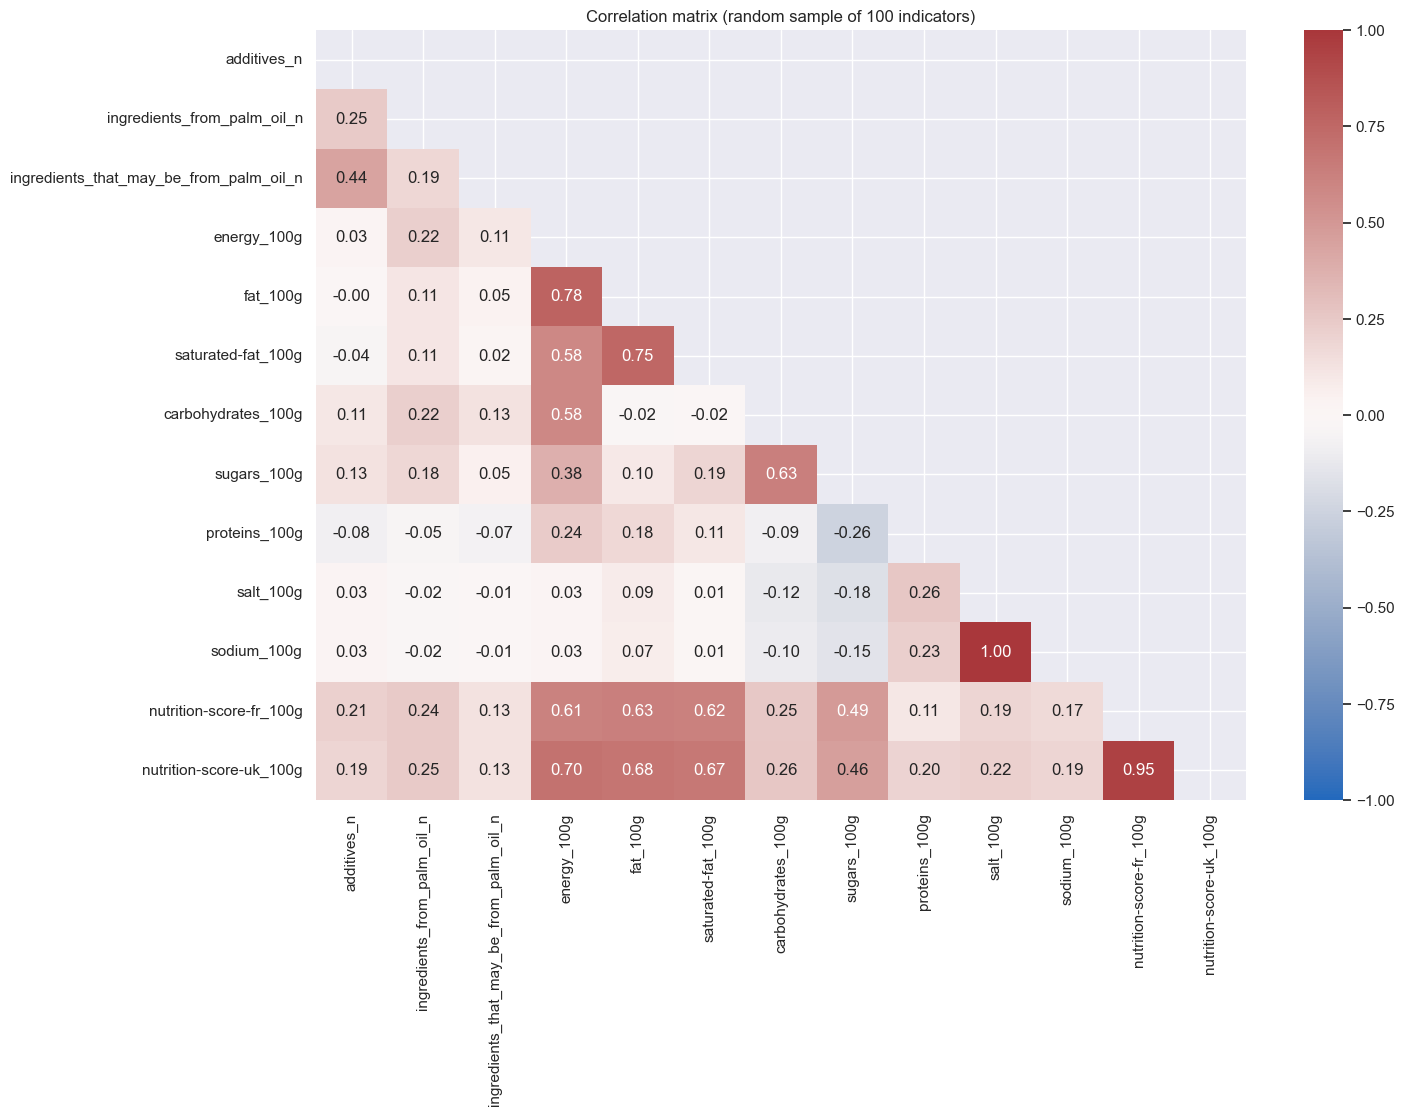

In [57]:
draw_heatmap(corr_matrix=filtered_data.corr(numeric_only=True), vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f")

In [39]:
def imputation(df:pd.DataFrame, features_to_estimate:list[str], group_columns:list[str], method:Callable=np.mean):
    '''
    Imputes missing values for specified features in a DataFrame using group averages or a specified method.

    Parameters:
    df (pd.DataFrame): Original DataFrame.
    features_to_estimate (str): Features for which missing data needs to be imputed.
    group_columns (str): Possible grouping variables for aggregation. All combinations will be attempted and the one with the lowest variation will be chosen for each missing value.
    method (Callable): Imputation method (e.g., mean, median). Defaults to np.mean.

    Returns:
    pd.DataFrame: DataFrame with imputed values for the specified indicator.
    '''
    if not set(group_columns).issubset(df.columns):
        raise ValueError("Argument 'group_columns' should only contain valid 'df' columns")
    
    df_copy = df.copy()

    missing_data = df_copy.loc[df_copy[features_to_estimate].isna().any(axis=1)]

    filtered_df = df_copy.loc[df_copy[group_columns].isin()]
    

    missing_data.loc[:, "group_id_set"] = missing_data.loc[:, group_columns].fillna('nan').apply(set, axis=1)

    df_cvs_medians = pd.DataFrame()

    # Partial function for method_if_criteria_met
    method_func = partial(method_if_criteria_met, method=method)

    for i in range(1, len(group_columns) + 1):
        for combo in combinations(group_columns, i):
            print(f'''Processing combination: "{'", "'.join(list(combo))}"''')
            df_copy["group_id"] = df_copy[list(combo)].fillna('nan').agg("_|_".join, axis=1)

            # Group by current combination and apply the function
            group = df_copy[["group_id"] + features_to_estimate].groupby("group_id").agg([coef_var, method_func])

            if df_cvs_medians.empty:
                df_cvs_medians = group
            else:
                df_cvs_medians = pd.concat([df_cvs_medians, group])

    df_cvs_medians = df_cvs_medians.dropna(how="all")

    for i in missing_data.index:
        group_id_set = missing_data.loc[i, "group_id_set"]
        matching_rows = df_cvs_medians.loc[df_cvs_medians.index.map(lambda x: set(x.split("_|_")).issubset(group_id_set))]

        missing_features = missing_data[features_to_estimate].loc[i].isna().index
        
        for feature in missing_features:
            sub_df = matching_rows[feature]
            values = sub_df.loc[sub_df["coef_var"] == sub_df["coef_var"].min(), "method_if_criteria_met"].values
            if len(values) > 0:
                df_copy.loc[i, feature] = values[0]

    return df_copy

In [43]:
group_columns=["categories_tags", "countries_tags", "pnns_groups_2"]
features_to_estimate = ["sugars_100g", "fat_100g"]
# test = filtered_data.loc[filtered_data["countries_tags"] == "France", features_to_estimate].copy()
# cProfile.run('imputation(df=filtered_data, group_columns=group_columns, features_to_estimate=features_to_estimate)', sort="cumtime")

In [45]:
df_copy = filtered_data.copy()

missing_data = df_copy.loc[df_copy[features_to_estimate].isna().any(axis=1)]

missing_data.loc[:, "group_id_set"] = missing_data.loc[:, group_columns].fillna('nan').apply(set, axis=1)

missing_data.value_counts(group_columns)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_13152\1660540425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_data.loc[:, "group_id_set"] = missing_data.loc[:, group_columns].fillna('nan').apply(set, axis=1)


categories_tags                                                                                                                                                                                                                                               countries_tags      pnns_groups_2        
en:sugary-snacks,en:confectioneries,en:candies                                                                                                                                                                                                                France              Sweets                   167
en:plant-based-foods-and-beverages,en:plant-based-foods,en:fats,en:olive-tree-products,en:vegetable-fats,en:vegetable-oils,en:olive-oils,en:extra-virgin-olive-oils                                                                                           France              Fats                     143
en:plant-based-foods-and-beverages,en:beverages,en:plant-based-beverages,en:fruit-based-beverages,

In [ ]:

imputed_data = imputation(df=filtered_data, group_columns=group_columns, features_to_estimate=features_to_estimate)

Processing combination: "categories_tags"
Processing combination: "countries_tags"
Processing combination: "pnns_groups_2"
Processing combination: "categories_tags", "countries_tags"
Processing combination: "categories_tags", "pnns_groups_2"
Processing combination: "countries_tags", "pnns_groups_2"
Processing combination: "categories_tags", "countries_tags", "pnns_groups_2"


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21204\334995877.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_data["group_id_set"] = missing_data[group_columns].fillna('nan').apply(set, axis=1)


,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,...,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,group_id
174,290616,Salade Cesar,Laitue en salade,0.980 kg,frais,kirkland-signature,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,Costco,...,12.000000,7.0,23.0,NaN,22.00,2.1600,0.850,6.0,6.0,"en:plant-based-foods-and-beverages,en:plant-ba..."
175,394710,Danoises à la cannelle roulées,Pâtisserie,1.150 kg,frais,kirkland-signature,"en:sugary-snacks,en:biscuits-and-cakes,en:past...",NaN,Brossard Québec,Costco,...,14.400000,NaN,54.1,28.1,4.79,0.9220,0.363,NaN,NaN,"en:sugary-snacks,en:biscuits-and-cakes,en:past..."
177,1071894,Flute,Flute,NaN,"paper,plastic-film",waitrose,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,"Brent,UK",Waitrose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
180,1938067,Chaussons tressés aux pommes,Pâtisserie,1.200 kg,frais,kirkland-signature,"en:sugary-snacks,en:biscuits-and-cakes,en:past...",NaN,Brossard Québec,Costco,...,10.700000,2.0,38.7,24.7,3.33,0.6470,0.255,9.0,9.0,"en:sugary-snacks,en:biscuits-and-cakes,en:past..."
182,5200016,lentilles vertes,NaN,1 kg,sachet-plastique,bertrand-lejeune,"en:plant-based-foods-and-beverages,en:plant-ba...","en:organic,en:eu-organic,fr:ab-agriculture-bio...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320736,9901198001583,Лимон — лайм,NaN,2,NaN,пеликан,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
320740,99111250,Thé vert Earl grey,thé bio équitable,50 g,"boite,carton",lobodis,"en:plant-based-foods-and-beverages,en:beverage...","en:fair-trade,en:organic,en:eu-organic,en:max-...",NaN,NaN,...,0.200000,0.2,0.5,0.5,0.50,0.0254,0.010,2.0,0.0,"en:plant-based-foods-and-beverages,en:beverage..."
320742,9935010000003,Rillette d'oie,NaN,180 g,"pot,verre","sans-marque,d-lambert","en:meats,en:spreads,en:prepared-meats,en:salte...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:meats,en:spreads,en:prepared-meats,en:salte..."
320743,99410148,NaN,NaN,NaN,plastique,NaN,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,NaN,...,47.123810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."


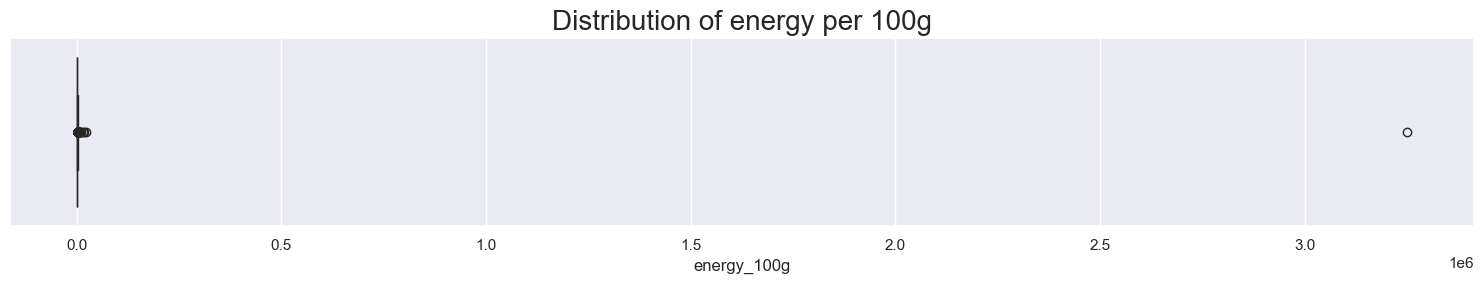

In [71]:
fig, ax = plt.subplots(figsize=(15,3))

sns.boxplot(data=filtered_data, x="energy_100g", ax=ax)
ax.set_title("Distribution of energy per 100g", fontsize=20)
# fig.supxlabel("Nutrients quantity")
fig.tight_layout()

In [72]:
filtered_data.loc[filtered_data["energy_100g"] > 1.5e6]

,code,product_name,brands_tags,energy_100g,carbohydrates_100g,fat_100g,fiber_100g,proteins_100g,saturated-fat_100g,sugars_100g,pnns_groups_1,pnns_groups_2,states_tags,categories_tags,countries_tags
212905,3257983143096,Pois cassés,cora,3251373.0,48.2,1.2,15.4,22.7,0.2,2.5,NaN,NaN,"en:to-be-checked,en:complete,en:nutrition-fact...",fr:pois-casses,France


In [73]:
filtered_data.loc[filtered_data["energy_100g"] < 1.5e6]

,code,product_name,brands_tags,energy_100g,carbohydrates_100g,fat_100g,fiber_100g,proteins_100g,saturated-fat_100g,sugars_100g,pnns_groups_1,pnns_groups_2,states_tags,categories_tags,countries_tags
174,290616,Salade Cesar,kirkland-signature,1210.0,23.00,12.00,2.000,22.000,7.000,0.000,Fruits and vegetables,Vegetables,"en:to-be-checked,en:complete,en:nutrition-fact...","en:plant-based-foods-and-beverages,en:plant-ba...",Canada
175,394710,Danoises à la cannelle roulées,kirkland-signature,1520.0,54.10,14.40,2.050,4.790,NaN,28.100,Sugary snacks,Biscuits and cakes,"en:to-be-checked,en:complete,en:nutrition-fact...","en:sugary-snacks,en:biscuits-and-cakes,en:past...",Canada
180,1938067,Chaussons tressés aux pommes,kirkland-signature,1090.0,38.70,10.70,2.000,3.330,2.000,24.700,Sugary snacks,Biscuits and cakes,"en:to-be-checked,en:complete,en:nutrition-fact...","en:sugary-snacks,en:biscuits-and-cakes,en:past...",Canada
181,4302544,Pain Burger Artisan,kirkland-signature,1160.0,53.30,1.11,2.220,10.000,0.333,1.110,NaN,NaN,"en:to-be-checked,en:complete,en:nutrition-fact...",fr:boulange,Canada
185,8237798,Quiche Lorraine,kirkland-signature,478.0,7.86,6.79,0.357,5.360,2.860,0.714,Composite foods,Pizza pies and quiche,"en:to-be-checked,en:complete,en:nutrition-fact...","en:meals,en:pizzas-pies-and-quiches,en:quiches...",Canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320679,96118580,Fisherman's Friend Miel-Citron,fisherman-s-friend,1031.0,95.31,1.30,1.470,0.004,1.280,0.100,Sugary snacks,Sweets,"en:to-be-checked,en:complete,en:nutrition-fact...","en:sugary-snacks,en:confectioneries,en:candies...",NaN
320694,9688014090357,100 г очищенных жареных семечек,семечек-стакан,2970.0,6.00,65.00,NaN,26.000,NaN,NaN,NaN,NaN,"en:to-be-completed,en:nutrition-facts-complete...","en:plant-based-foods-and-beverages,en:plant-ba...",NaN
320711,9778564312457,Nature cheddar and red onion crisps,marks-and-spencer,2155.0,NaN,NaN,5.600,7.800,3.400,1.800,Salty snacks,Appetizers,"en:to-be-completed,en:nutrition-facts-complete...","en:salty-snacks,en:appetizers,en:chips-and-fri...",NaN
320728,9847548283004,Tartines craquantes bio au sarrasin,le-pain-des-fleurs,1643.0,74.80,2.80,5.900,13.000,0.600,2.600,Cereals and potatoes,Bread,"en:to-be-completed,en:nutrition-facts-complete...","en:plant-based-foods-and-beverages,en:plant-ba...",NaN


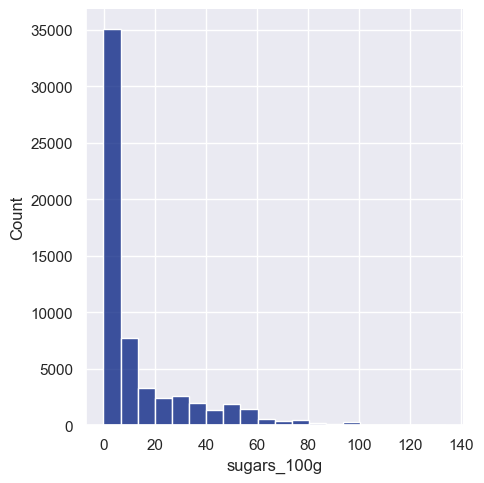

In [56]:
sns.displot(data=filtered_data, x="sugars_100g", kind='hist', bins=20)

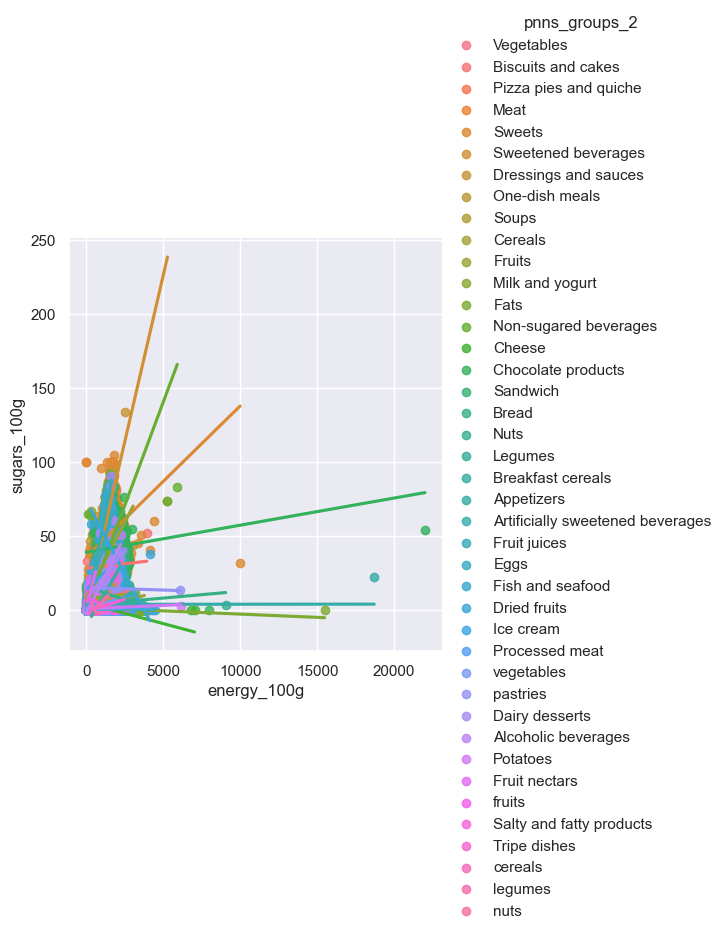

In [78]:
sns.lmplot(data=filtered_data.loc[filtered_data["energy_100g"] < 1.5e6], x="energy_100g", y="sugars_100g", hue="pnns_groups_2", ci=None)